# Easy as 1-2-3? Vision-Language Models for Historical Text Recognition

### Bas Vercruysse [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0009-0009-8744-6681) 
Ghent Centre for Digital Humanities, Ghent University

### Vincent Ducatteeuw [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-4493-6268) 
Ghent Centre for Digital Humanities, Ghent University,
Antwerp Cultural Heritage Sciences, University of Antwerp

### Johan Poukens [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0002-4663-9665) 
Study Center for Companies and Exchanges, University of Antwerp

### Christophe Verbruggen [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-0849-6365) 
Ghent Centre for Digital Humanities, Ghent University

### Julie M. Birkholz [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-1193-0847) 
Ghent Centre for Digital Humanities, Ghent University, KBR Royal Library

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©<Bas Vercruysse - Vincent Ducatteeuw - Johan Poukens - Christophe Verbruggen - Julie Birkholz>. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


Vision-language models (VLMs), Historical text recognition, Belgian Official Gazette, Economic history, AI hallucinations

This article examines how vision–language models (VLMs) – AI systems that process both images and text – can be used for historical text recognition. We test these models on company records collected from the Belgian Official Gazette (1873-1991), collected as part of the BelHisFirm project. While VLMs recognize text more accurately than traditional systems, historians lack clear standards for using them. Researchers need to understand how these models generate text, yet practices for selecting models, designing prompts, understanding and validating results vary widely. We address this gap by comparing tree VLMs (DeepSeek-OCR, Qwen-VL, CHURRO) with two traditional systems (Tesseract, Kraken) and one Vision Transformer (TrOCR). By visualising model attention and token probabilities, we examine how visual input and prompt design influence VLM behavior and error patterns. The comparison reveals a critical trade-off: VLMs excel at reading poor-quality prints and irregular layouts, but they produce “hallucinations”, text that looks plausible but doesn’t match the original document. Traditional systems make predictable character-level errors, which can be corrected using dictionaries or rules. In contrast, VLM hallucinations are often hard to detect and filter. We argue that incorporating VLMs into historical text recognition requires adapting traditional ATR workflows to address these challenges.

## Introduction

Legal gazettes, business registers, corporate ledgers, and securities market listings form the foundational basis for consistent, long-run financial microdata (<cite id="negl6"><a href="#zotero%7C7368571%2FQTBNFV66">(Annaert et al., 2016)</a></cite>). Quantitative economic and financial history now relies heavily on converting these historical documents into structured data through digitization projects (<cite id="z6m4e"><a href="#zotero%7C7368571%2FJHS78G3R">(Poukens, 2020)</a></cite>, <cite id="pylba"><a href="#zotero%7C7368571%2F4VKHJEL2">(Ducros et al., 2018)</a></cite>, <cite id="n5o2d"><a href="#zotero%7C7368571%2FLRTAJ9MP">(Gram et al., 2022)</a></cite>). But this is not without challenges: blurred text, faded ink, bleed-through, uneven lighting, and general deterioration all complicate data extraction (<cite id="01oht"><a href="#zotero%7C7368571%2F2Z85PXZW">(Sulaiman et al., 2019)</a></cite>). Processing serial volumes of 19th- and early 20th-century printed materials remains especially difficult at scale. Here, the main issue lies not in recognizing fonts but handling complex and varying nonstandard layouts with multiple columns and tables that traditional text recognition systems cannot manage without extensive fine-tuning (<cite id="idfyp"><a href="#zotero%7C7368571%2FIFSKN8VV">(Fleischhacker et al., 2025)</a></cite>).




Over recent decades, digitization initiatives have made archival collections searchable through automatic text recognition (ATR)<sup>1</sup> (<cite id="rs9fr"><a href="#zotero%7C7368571%2FWBY8WWKM">(Adam et al., 2021)</a></cite>). Standard practice for historical ATR typically involves training specialized models on manually annotated examples at the paragraph or line level (<cite id="0f08l"><a href="#zotero%7C7368571%2F3FJRJZH5">(Neudecker et al., 2019)</a></cite>, <cite id="gz532"><a href="#zotero%7C7368571%2F4FBA8G5D">(Reul et al., 2019)</a></cite>, <cite id="h3egl"><a href="#zotero%7C7368571%2FASQIFTJ3">(Kiessling et al., 2019)</a></cite>). Traditional ATR separates two tasks: layout detection identifies text regions and line boundaries, while text recognition converts these segments into character sequences through pattern matching. Tools like Transkribus (<cite id="pgi7y"><a href="#zotero%7C7368571%2F3FEBWEZM">(Kahle et al., 2017)</a></cite>) and eScriptorium (<cite id="i1u9b"><a href="#zotero%7C7368571%2FASQIFTJ3">(Kiessling et al., 2019)</a></cite>) support manual annotation and model training, while frameworks like OCR4all (<cite id="ifonr"><a href="#zotero%7C7368571%2F4FBA8G5D">(Reul et al., 2019)</a></cite>) and OCR-D (<cite id="i5ikj"><a href="#zotero%7C7368571%2F3FJRJZH5">(Neudecker et al., 2019)</a></cite>) combine image processing, text recognition, and post-processing correction steps to improve results. But the need for annotated training data creates a persistent bottleneck.

Recent vision-language models (VLMs) that understand text on images without prior fine-tuning offer potential solutions (<cite id="awain"><a href="#zotero%7C7368571%2F7SB78Z58">(Zhang et al., 2025)</a></cite>, <cite id="rv6ao"><a href="#zotero%7C7368571%2F9B89XR2Q">(Shi et al., 2023)</a></cite>, <cite id="w3s9p"><a href="#zotero%7C7368571%2FIZQEB39J">(Ghiriti et al., 2024)</a></cite>). Compared to traditional ATR, VLMs adapt better to complex layouts and poor print quality (<cite id="g7vb3"><a href="#zotero%7C7368571%2F8QN6U8XA">(Jaillant &#38; Caputo, 2022)</a></cite>, <cite id="nvokd"><a href="#zotero%7C7368571%2FF8EYV7M7">(Ströbel et al., 2024)</a></cite>, <cite id="kqnzu"><a href="#zotero%7C7368571%2FCR3MFGJB">(Greif et al., 2025)</a></cite>). They have also been used to generate synthetic training data (<cite id="lwxga"><a href="#zotero%7C7368571%2FV9XXI237">(Bhardwaj et al., 2025)</a></cite>) and correct outputs from traditional ATR systems (<cite id="mxpar"><a href="#zotero%7C7368571%2FFC7E99KQ">(Boros et al., 2024)</a></cite>, <cite id="drabv"><a href="#zotero%7C7368571%2F2893Y324">(Thomas et al., 2024)</a></cite>, <cite id="400dl"><a href="#zotero%7C7368571%2FNZRG4YE8">(Kanerva et al., 2025)</a></cite>). While ATR benchmarks (<cite id="drp5a"><a href="#zotero%7C7368571%2FIW5455JH">(Yang et al., 2024)</a></cite>, <cite id="8oi2z"><a href="#zotero%7C7368571%2FRPHFHMVT">(Liu et al., 2025)</a></cite>, <cite id="mod7b"><a href="#zotero%7C7368571%2FXTF8IQKS">(Fu et al., 2025)</a></cite>) have become standard for evaluating VLMs, these benchmarks focus mainly on modern documents and rarely include historical materials. New datasets like CHURRO-DS (<cite id="2wx7u"><a href="#zotero%7C7368571%2FYLZMJABB">(Semnani et al., 2025)</a></cite>) are starting to address this gap, but they are still very recent.
Despite their advantages, VLMs create distinct problems for historical ATR (<cite id="nrj0i"><a href="#zotero%7C7368571%2FZXQJD4QD">(Jaillant &#38; Rees, 2023)</a></cite>) when high accuracy matters (e.g. numeric data). Similar to large language models (LLMs), VLMs can produce hallucinations (<cite id="dp8ah"><a href="#zotero%7C7368571%2FZUVKVRKX">(Bai et al., 2024)</a></cite>). We define VLM transcription hallucinations as cases where the model generates text that does not correspond to the text present in the image. These hallucinations stem from two sources: statistical biases in visual training data, such as common but superficial object correlations, and over-reliance on language patterns (i.e. language priors) embedded in the LLMs that decode visual information (<cite id="5tysw"><a href="#zotero%7C7368571%2FT3PSIMRW">(Leng et al., 2023)</a></cite>). Unlike traditional ATR errors, which involve predictable character-level substitutions (e.g., “i” → “j”; “3” → “5”) or missing text due to degraded documents, hallucinations invent plausible-looking figures, dates, or names that fit the context. Such errors undermine quality control and make it harder for historians to assess the reliability of digitized materials (<cite id="zo9ug"><a href="#zotero%7C7368571%2FP42LQNMN">(Alalaq, 2024)</a></cite>). If undetected, hallucinations in datasets can distort research findings and lead to flawed historical interpretations.
Our study examines how VLM-based ATR performs when extracting structured firm-level data from the Moniteur belge, the Belgian Official Gazette (1873-2002). As part of the BelHisFirm project, we compare traditional ATR systems (Tesseract-OCR, Kraken) and a vision transformer (ViT) model (TrOCR) with recently developed open-weight VLMs optimized for text recognition (DeepSeek-OCR, Qwen-VL, CHURRO). Our analysis reveals fundamental differences in how these systems “fail”. Conventional accuracy metrics like character error rate (CER) or word error rate (WER) don’t accurately capture these qualitative distinctions(<cite id="gn18x"><a href="#zotero%7C7368571%2FYBDDLPAP">(Levchenko, 2025)</a></cite>, <cite id="x1544"><a href="#zotero%7C7368571%2FYDT5NSKF">(Eriksson et al., 2025)</a></cite>).

We address three core questions

1. How do VLMs handle degraded printed serials compared to traditional ATR systems?
2. What types of errors do VLMs produce and how can we understand their causes?
3. Which validation strategies effectively distinguish VLM hallucinations from conventional ATR errors?

For historians, the adage “seeing is believing” has long guided the transcription process. However, VLMs can override visual evidence with linguistic assumptions, introducing content that was never present. While traditional ATR systems produce systematic, character-level errors that historians can identify and correct using established methods (<cite id="1bjqs"><a href="#zotero%7C7368571%2FHZJIBTKL">(P. B. Ströbel et al., 2024)</a></cite>), hallucinations from VLMs pose a fundamentally different challenge. These errors undermine conventional quality-control metrics, highlighting the need for new validation frameworks tailored to outputs that appear documentary but are entirely fabricated. Analysing hallucination patterns can therefore help us assess the implications of VLM-based ATR for historical research.

The paper proceeds as follows: Section 2 reviews traditional, ViT-based and VLM-based ATR technologies, emphasising their use in historical research and the distinctive error patterns they produce. Section 3 describes our corpus, experimental design, and evaluation framework that goes beyond conventional accuracy metrics. Section 4 presents our findings, highlighting the differences between deterministic ATR and ViT errors and VLM hallucinations and examining their implications for data quality. Finally, Section 5 concludes by discussing the methodological consequences for historians adopting VLM-based ATR and proposes specific evaluation steps.

## Related Work

#### Traditional ATR

Established ATR systems such as Tesseract (<cite id="ni7ds"><a href="#zotero%7C7368571%2FQJJSBFLG">(Smith, 2007)</a></cite>) and Transkribus (<cite id="t1k8h"><a href="#zotero%7C7368571%2F3FEBWEZM">(Kahle et al., 2017)</a></cite>) have been central to archival digitization for decades. These systems use supervised learning to map visual features to text, often employing convolutional neural networks (CNNs) to improve recognition accuracy. Performance improves further through pre- and post-processing steps, including noise reduction, layout segmentation, and dictionary-based post-correction (<cite id="mt87b"><a href="#zotero%7C7368571%2F4NAU5CJA">(Bassil &#38; Alwani, 2012)</a></cite>). 

Despite their usefulness, traditional ATR systems struggle with certain historical materials. Recognition accuracy drops sharply when documents have mixed typefaces, irregular layouts, physical damage and tables, all common in 19th- and early 20th-century printed serials. Character-level errors most often involve substitutions, where visually similar characters get confused (e.g., “i” and “j”, or “e” and “c”), reflecting common confusion pairs in hard-to-read historical fonts. Error rates also vary systematically across character types, with punctuation marks and diacritics recognized far less accurately than letters and numbers (<cite id="lekvp"><a href="#zotero%7C7368571%2FBAWMLDYN">(Nguyen et al., 2019)</a></cite>).

However, the fact that traditional ATR systems produce deterministic, reproducible errors is advantageous. Character substitutions, deletions, insertions, and spacing problems occur in predictable patterns, allowing systematic correction through rule-based methods or dictionary validation. This predictability makes error profiles manageable for quality control workflows. Post-correction procedures, whether manual or automatic, exploit these patterns using statistical error modeling, language modeling or word-level approaches (<cite id="j4lk6"><a href="#zotero%7C7368571%2FSXNVLACU">(Rigaud et al., 2019)</a></cite>, <cite id="9uqzi"><a href="#zotero%7C7368571%2FVHVXMQD3">(T.-T.-H. Nguyen et al., 2019)</a></cite>). Many traditional ATR systems also provide probability or confidence scores for individual characters or words, enabling targeted intervention on low-confidence predictions.


#### Vision-Language Models

VLMs extend traditional ATR by combining image encoders with LLMs to generate text from visual inputs (<cite id="0ymmw"><a href="#zotero%7C7368571%2F7J4HPB2E">(Y. Zhang et al., 2025)</a></cite>). VLMs jointly process and align visual and textual information, making ATR tasks inherently multimodal (<cite id="aws4r"><a href="#zotero%7C7368571%2FFM8KLSP9">(Baltrusaitis et al., 2019)</a></cite>), even though traditional (vision-only) ATR systems handle them within a single visual modality. Built on transformer architectures and trained on massive multimodal datasets, VLMs achieve advanced image understanding through scaling both parameters and data (<cite id="9jsli"><a href="#zotero%7C7368571%2FIUWWL6AV">(Vaswani et al., 2023)</a></cite>). Recent VLM architectures increasingly process entire pages, eliminating even the bounding-box detection step that traditional pipelines require. By linking visual and textual features, VLMs support not only text recognition but also visual question answering and structured document interpretation (<cite id="pzp6m"><a href="#zotero%7C7368571%2FRPHFHMVT">(Liu et al., 2025)</a></cite>, <cite id="gp7m8"><a href="#zotero%7C7368571%2FXTF8IQKS">(Fu et al., 2025)</a></cite>, <cite id="kn9r8"><a href="#zotero%7C7368571%2FTC5YN5WB">(Dell, 2024)</a></cite>).

This integration of visual and textual understanding offers advantages for challenging historical materials. VLMs handle irregular layouts, mixed typefaces, degraded print, and tables more flexibly than traditional systems (<cite id="wuxkg"><a href="#zotero%7C7368571%2FRPHFHMVT">(Liu et al., 2025)</a></cite>, <cite id="3f1g6"><a href="#zotero%7C7368571%2F9B89XR2Q">(Shi et al., 2023)</a></cite>, <cite id="vo1xh"><a href="#zotero%7C7368571%2FIZQEB39J">(Ghiriti et al., 2024)</a></cite>, <cite id="zah0k"><a href="#zotero%7C7368571%2FFC7E99KQ">(Boros et al., 2024)</a></cite>). For Latin-script documents, transformer-based models outperform sequential architectures such as PyLaia and HTR+, largely because they are pre-trained on multilingual datasets (<cite id="n2itl"><a href="#zotero%7C7368571%2FYYUXMRK8">(Romein et al., 2025)</a></cite>). Beyond direct text recognition (<cite id="zyu2m"><a href="#zotero%7C7368571%2FVJILK7TN">(Humphries et al., 2025)</a></cite>, <cite id="4xwps"><a href="#zotero%7C7368571%2FAZAWNYNA">(Sohail et al., 2024)</a></cite>, <cite id="8ml5e"><a href="#zotero%7C7368571%2FMBB3ITMW">(Kim et al., 2025)</a></cite>). VLMs have been applied across the digitization pipeline. Researchers use them for document classification (<cite id="7tz7r"><a href="#zotero%7C7368571%2FJNCEJLFV">(Scius-Bertrand et al., 2025)</a></cite>), layout segmentation, and post-correction of traditional ATR outputs (<cite id="bscfd"><a href="#zotero%7C7368571%2FKW2CQ2SX">(Soper et al., 2021)</a></cite>, <cite id="p3w9t"><a href="#zotero%7C7368571%2FFC7E99KQ">(Boros et al., 2024)</a></cite>, <cite id="zvcn1"><a href="#zotero%7C7368571%2FNZRG4YE8">(Kanerva et al., 2025)</a></cite>). They generate synthetic training data to augment limited historical corpora (<cite id="plnwo"><a href="#zotero%7C7368571%2FV9XXI237">(Bhardwaj et al., 2025)</a></cite>) and transform unstructured ATR output into machine-readable formats like JSON for downstream tasks (<cite id="nu2pt"><a href="#zotero%7C7368571%2F9B89XR2Q">(Shi et al., 2023)</a></cite>, <cite id="ig318"><a href="#zotero%7C7368571%2FIZQEB39J">(Ghiriti et al., 2024)</a></cite>).

A defining feature of VLMs is their adaptability through prompting, adjusting model behavior via input instructions without retraining (<cite id="m0czk"><a href="#zotero%7C7368571%2FZ9Z5F2Y3">(Gu et al., 2023)</a></cite>, <cite id="oh6ef"><a href="#zotero%7C7368571%2FKHQLXDE9">(Schulhoff et al., 2025)</a></cite>, <cite id="azglr"><a href="#zotero%7C7368571%2FVUMRD8JQ">(Sahoo et al., 2025)</a></cite>). Zero-shot approaches provide only task instructions, while few-shot methods include example input-output pairs (<cite id="vbbti"><a href="#zotero%7C7368571%2F7RQFA8FK">(Z. Liu et al., 2025)</a></cite>, <cite id="18wff"><a href="#zotero%7C7368571%2FPXIH944A">(Brown et al., 2020)</a></cite>, <cite id="kroso"><a href="#zotero%7C7368571%2F3C8KWK9T">(Gao et al., 2021)</a></cite>, ). For historical documents, task-specific instructions, such as line-by-line transcription directives, layout-preserving commands or domain constraints, can improve performance (<cite id="b72oc"><a href="#zotero%7C7368571%2FMBB3ITMW">(Kim et al., 2025)</a></cite>). (<cite id="cphxf"><a href="#zotero%7C7368571%2FBDHQ3Y3N">(Bourne, 2025)</a></cite>) found that providing socio-cultural context in prompts improved post-correction performance (though this was tested on text correction rather than text recognition), while misleading context decreased accuracy. (<cite id="5aulu"><a href="#zotero%7C7368571%2FHQ3WKAKC">(Bäcker-Peral et al., 2025)</a></cite>) even demonstrate that VLMs offer an effective, low-cost approach to extracting historical tabular data by leveraging domain expertise through natural-language prompts, rather than requiring the technical skills needed for traditional table extraction (e.g. LayoutParser, <cite id="0r2ha"><a href="#zotero%7C7368571%2F7ZKT99MJ">(Shen et al., 2021)</a></cite>, <cite id="4y5ak"><a href="#zotero%7C7368571%2FXU42E3Y9">(Correia &#38; Luck, 2023)</a></cite>).

However, prompting introduces significant methodological challenges. The same model can produce markedly different outputs depending on how instructions are phrased and formatted (<cite id="561m7"><a href="#zotero%7C7368571%2FA4JLX7VT">(Zhou et al., 2023)</a></cite>), shifting some of the responsibility of ATR performance from model architecture to prompt design. Standardised prompting protocols for historical ATR are still underdeveloped, and it remains uncertain whether such protocols will be necessary once VLMs fine-tuned for specific tasks, such as ATR, become widely available. Additionally, the use of VLMs via chatbot interfaces further complicates reproducibility, as outputs can vary across sessions due to opaque model updates and automatic prompt optimization (<cite id="a1vlf"><a href="#zotero%7C7368571%2FMBB3ITMW">(Kim et al., 2025)</a></cite>).

A growing body of theoretical work situates the ATR weaknesses of VLMs within a broader mechanism: their tendency to default to language priors when visual evidence is weak or ambiguous. Under conditions of visual degradation, such as blur, low resolution, or out-of-domain imagery, models increasingly rely on semantic patterns rather than the visual signal. (<cite id="un6vi"><a href="#zotero%7C7368571%2FLXR8Q7CA">(Inoue, 2025)</a></cite>), for example, found that VLM-based ATR deteriorates substantially below 150 ppi for individual Kanji characters, likely due to the characters’ high visual complexity. This linguistic fallback can bias recognition toward plausible but incorrect vocabulary over arbitrary character sequences (<cite id="4of8x"><a href="#zotero%7C7368571%2FTLXYHJUZ">(Y. Liu et al., 2024)</a></cite>) Empirical analyses confirm this modality imbalance: VLMs often privilege the linguistic patterns encoded in their LLM backbones even when these conflict with the input image (<cite id="ljgk6"><a href="#zotero%7C7368571%2FUH9PVFCW">(Lee et al., 2025)</a></cite>). (<cite id="vyszd"><a href="#zotero%7C7368571%2F62Q6G7L4">(Zheng et al., 2025)</a></cite>) further show that this bias decreases with larger language backbones, while exhibiting no consistent relationship with image-encoder size. (<cite id="nmowd"><a href="#zotero%7C7368571%2FT3PSIMRW">(Leng et al., 2023)</a></cite>) similarly demonstrate that heightened visual uncertainty increases hallucination rates as models revert to prior linguistic patterns.

Comparative evaluations of historical handwriting transcription reflect these broader limitations (<cite id="gered"><a href="#zotero%7C7368571%2FI4RX3CRK">(Crosilla et al., 2025)</a></cite>). report no consistent advantage of VLMs or LLM-based systems over traditional systems such as Transkribus when processing multilingual handwritten corpora, with particularly weak results on non-English scripts, likely due to the English-centric pretraining of most LLM backbones. Beyond recognition accuracy, VLMs also introduce workflow-specific constraints: current systems cannot reliably extract layout coordinate data, limiting their applicability in digitization pipelines requires precise spatial information (<cite id="ezlzj"><a href="#zotero%7C7368571%2FIZQEB39J">(Ghiriti et al., 2024)</a></cite>). 

Most critically for historical research requiring high data accuracy, VLMs introduce a distinctive error type: hallucinations. Characterized as errors in probabilistic inference <cite id="eih3r"><a href="#zotero%7C7368571%2FJAHGQNRY">(Kalai et al., 2025)</a></cite>, hallucinations arise from model pretraining and occur particularly under visual degradation such as blur, occlusion, or low contrast (<cite id="jjlzi"><a href="#zotero%7C7368571%2F6TX2ANB3">(Ji et al., 2023)</a></cite>, <cite id="tqbyq"><a href="#zotero%7C7368571%2FD6TP7XYU">(Cui et al., 2023)</a></cite>, <cite id="7mtpe"><a href="#zotero%7C7368571%2FKQ4ASD5H">(He et al., 2025)</a></cite>). (<cite id="t7dus"><a href="#zotero%7C7368571%2FHWSSUQH4">(Favero et al., 2024)</a></cite>) show that as more output is generated, reliance on the visual image decreases, and this trend strongly correlates with hallucination emergence. (<cite id="85jxt"><a href="#zotero%7C7368571%2FYBDDLPAP">(Levchenko, 2025)</a></cite>) documented "over-historicization" hallucinations where VLMs inserted anachronistic characters from incorrect historical periods when transcribing 18th-century Russian Civil font texts. Levchenko also found that VLM-based post-processing degraded rather than improved transcription quality. Similarly, (<cite id="ndu0g"><a href="#zotero%7C7368571%2FFC7E99KQ">(Boros et al., 2024)</a></cite>) reported that LLM-based post-correction often produced worse results than traditional methods for historical transcriptions.

Recent interpretability research has begun to shed light on the mechanisms underlying VLM-based ATR. Attention map visualizations show where models “focus” when generating text tokens, with the expectation that attention is primarily directed to relevant visual regions corresponding to each text token (<cite id="n2e7p"><a href="#zotero%7C7368571%2F6B5KSBEN">(Stan et al., 2024)</a></cite>, <cite id="ylg3i"><a href="#zotero%7C7368571%2F62Q4CU9K">(Aflalo et al., 2022)</a></cite>). However, empirical analyses reveal counterintuitive patterns: VLMs often disproportionately attend to specific visual tokens (a phenomenon known as visual attention sink) regardless of textual context, with some tokens consistently receiving high attention weights across all generated text tokens (<cite id="51q1k"><a href="#zotero%7C7368571%2FNF5VIQJD">(Kang et al., 2025)</a></cite>). (<cite id="f9f54"><a href="#zotero%7C7368571%2F37AF8D2B">(Baek et al., 2025)</a></cite>) identified specialized “OCR heads” in VLMs, attention mechanisms that selectively attend to visual tokens corresponding to specific characters during ATR. Unlike retrieval heads in text-only LLMs, which remember tokens from input prompts, OCR heads must process visual patterns directly. Other studies show that VLMs frequently fail to attend adequately to visual information (<cite id="x8zsd"><a href="#zotero%7C7368571%2FR9G9B3XJ">(Chen et al., 2025)</a></cite>), motivating interventions such as attention weight amplification (<cite id="c07oh"><a href="#zotero%7C7368571%2FCQHW5MPG">(Zhu et al., 2024)</a></cite>) to encourage greater reliance on visual cues. Understanding these attention patterns is critical for evaluating VLM errors in historical ATR, as cross-modal attention mechanisms may explain when VLMs will likely generate linguistically plausible hallucinations rather than correct text.


## Methodology

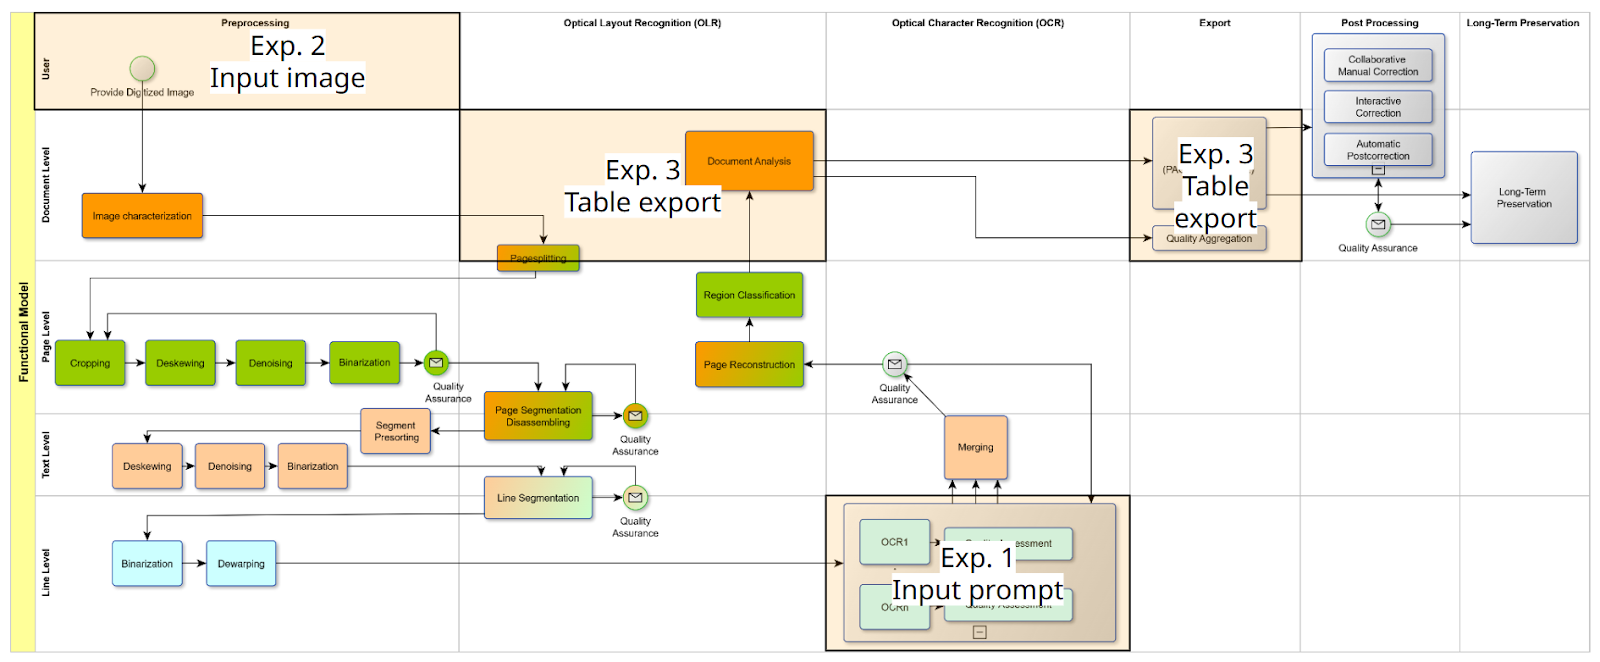

In [4]:
from IPython.display import Image

metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "OCR-D workflow showing sequential processing stages (e.g., preprocessing, OLR, OCR) and operational levels (document, page, text, and line). Orange boxes denote document-level processing, including for our three experiments."
            ]
        }
    }
}

display(Image("media/OCR-D-figure.png", width=1000), metadata=metadata)

#### Design


We examine how VLMs, ViTs and traditional ATR systems perform when extracting structured firm-level data from 20th century corporate records.<sup>2</sup> Rather than focusing on comparing individual models, our experiments focus on differences between recognition paradigms and their underlying assumptions. Specifically, we analyse how prompting strategies and image quality affect recognition accuracy across VLM, ViT, and ATR architectures. The goal is not to rank specific systems, but to assess the strengths and limitations of these systems for modern ATR workflows. Our experimental design comprises three experiments, each targeting a specific stage of the traditional OCR-D Workflow.

1. Input prompt: How do variations in textual prompts, particularly the inclusion of contextual information, affect the accuracy and robustness of VLM-based ATR systems?
2. Input image: How do variations in intrinsic and extrinsic image quality (such as blur, fading, tears, and other forms of degradation) influence the performance of VLM-based ATR systems?
3. Table export: To what extent do VLM-based ATR models correctly interpret tabular layouts and generate structurally accurate table representations in their outputs?

To evaluate VLM performance on ATR tasks, we use standard error metrics defined in the OCR-D Quality Assurance Standard (<cite id="v68ge"><a href="#zotero%7C7368571%2F3FJRJZH5">(Neudecker et al., 2019)</a></cite>). These metrics assess model accuracy at both the character and word levels, providing a comprehensive measure of textual fidelity:

**Character Error Rate (CER):** measures the proportion of character-level errors in predicted text compared to the ground truth. Errors include insertions, deletions, and substitutions of individual characters. It is calculated as:

$$
\mathrm{CER} = \frac{S + D + I}{N}
$$


Where:
- $S$ = number of substitutions
- $D$ = number of deletions
- $I$ = number of insertions
- $N$ = total number of characters in the reference text
CER reflects the fine-grained transcription accuracy of an OCR system.

**Word Error Rate (WER):** WER is similar to CER but at the word level. It measures the number of word-level edits needed to align the predicted text with the reference text. WER is defined as:

$$
\mathrm{WER} = \frac{S_w + D_w + I_w}{N_w}
$$


Where:
- $S_w$ = number of word substitutions
- $D_w$= number of word deletions
- $I_w$ = number of word insertions
- $N_w$ = total number of words in the reference text


WER serves as an indicator of the semantic readability of ATR output by capturing errors at the word level. For example, if the ground-truth word “bank” is consistently transcribed as “bonk” due to a systematic substitution of the character “a” with “o”, the resulting transcription may yield a low CER while still producing a high WER. In such cases, despite apparent accuracy at the character level, the output remains semantically misleading and difficult to interpret.

For both CER and WER, particular care was taken to account for cases in which the predicted text substantially exceeds the length of the reference transcription, a situation that can lead to disproportionately large error values. VLMS are especially prone to this behaviour, as they may prepend meta-textual phrases such as “The transcription of the image is:” or “The text in the image is:” before producing the actual transcription. To address this, such model-specific output artefacts were considered during post-processing to ensure that the resulting error measurements reflect transcription quality rather than prompt-induced verbosity.

In [5]:
from jiwer import cer, wer
import pandas as pd

# This function uses jiwer to compute the cer and wer of two lists containing lists

def compute_metrics(ref_lines, hyp_lines):
    max_len = max(len(ref_lines), len(hyp_lines))
    all_refs = []
    all_hyps = []
    per_line_results = []

    for i in range(max_len):
        ref_line = ref_lines[i] if i < len(ref_lines) else ""
        hyp_line = hyp_lines[i] if i < len(hyp_lines) else ""

        # Skip pairs where reference is empty
        if not ref_line or not ref_line.strip():
            continue

        all_refs.append(ref_line)
        all_hyps.append(hyp_line)

        # Per-line jiwer metrics (do NOT cap at 1.0)
        line_cer = cer(ref_line, hyp_line)
        line_wer = wer(ref_line, hyp_line)
        
        per_line_results.append({
            "ref": ref_line,
            "hyp": hyp_line,
            "cer": line_cer,
            "wer": line_wer,
            "ref_len": len(ref_line),
        })

    df = pd.DataFrame(per_line_results)

    if not all_refs:
        return 0.0, 0.0, 0.0, df

    # Overall metrics
    overall_cer = df['cer'].mean()
    overall_wer = df['wer'].mean()

    return overall_cer, overall_wer, df


Beyond standard evaluation metrics, we adopt Tree Edit Distance Similarity (TEDS) to quantify structural similarity between predicted and ground-truth tables (<cite id="0bdyj"><a href="#zotero%7C7368571%2FI48UXJ77">(Zhong et al., 2020)</a></cite>, <cite id="dhxcm"><a href="#zotero%7C7368571%2FGWBJL8VQ">(Nassar et al., 2022)</a></cite>). Traditional layout-understanding approaches are predominantly spatial in nature, relying on metrics such as Intersection over Union (IoU) and Precision-Recall, which assess the geometric accuracy of detected text regions, paragraphs or tables based on bounding-box overlap (<cite id="pcg9l"><a href="#zotero%7C7368571%2F62C2PBEQ">(Vesalainen et al., 2024)</a></cite>). Although effective for layout detection, these metrics offer limited insight into whether a model has correctly captured the underlying logical structure of tabular data.

To address this limitation, recent research has shifted toward semantic representations of table structures from a natural language processing perspective (<cite id="wscy7"><a href="#zotero%7C7368571%2FQASDEYKJ">(Xue et al., 2021)</a></cite>). For instance, (<cite id="z1v6c"><a href="#zotero%7C7368571%2FRJXRDCUF">(Li et al., 2020)</a></cite>) encode tables as sequences of HTML tags representing rows, columns, and cell types, enabing structure-aware comparison independent of spatial layout. Building on this line of work, we apply TEDS to evaluate how accurately VLMs interpret and reproduce the tabular structure of our historical sources. By commuting edit distances between tree representations of predicted and ground-truth tables, TEDS provides a structure-aware similarity measure that is particularly well suited to assessing table understanding in VLM-based ATR systems.

In addition, we incorporate attention-based interpretability analysis to examine how VLMs ground their generated text in visual evidence and how prompt variations influence this process. Cross-model attention maps visualise the weights that transformer-based models assign to image regions for each generated token, highlighting the visual features deemed most most relevant for the generation of specific text tokens. These attention weights allow us to visualise shifts in model focus as a heatmap across the image and identify regions associated with specific lexical choices ([Figure 2](#anchor-figure-gradient-based)).

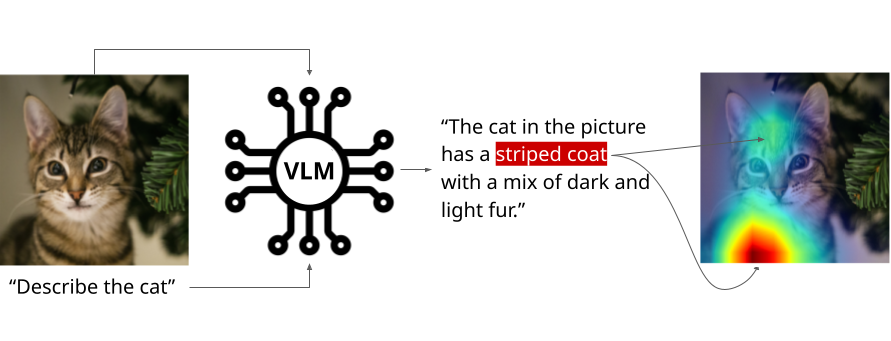

In [6]:
from IPython.display import Image

metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Gradient-based cross-modal relevancy map for the author’s cat. Warm colors mark image regions most associated with the generated tokens “striped” and “coat,” highlighting the visual features the model attended to when producing these words."
            ]
        }
    }
}

display(Image("media/relevancy-mapping.png", width=1000), metadata=metadata)

Following the LVLM-Interpret framework (<cite id="mciy3"><a href="#zotero%7C7368571%2F6B5KSBEN">(Stan et al., 2024)</a></cite>), adapted to the selected VLMs, we compute gradient-based cross-modal attention to obtain a more faithful estimate of the image regions that causally influence token generation (i.e. transcription). In contrast to raw attention weights, which primarily indicate how a model distributes focus, gradient-based measures capture the sensitivity of the generated output to variations in specific visual features. This allows us to identify image regions that exert the strongest influence on textual predictions.

Despite their use, attention-based interpretability methods have well-documented limitations. Similar to saliency maps, gradient-based attention provides only local, instance-level explanations and can be highly sensitive to small input variations (<cite id="x8z59"><a href="#zotero%7C7368571%2FFUMTAW54">(Lipton, 2017)</a></cite>). Moreover, attention distributions do not consistently reflect the features that ultimately drive model decisions (<cite id="37l3w"><a href="#zotero%7C7368571%2FI64ZHCQT">(Jain &#38; Wallace, 2019)</a></cite>). Recent work has therefore characterised the interpretation of attention maps as “more of an art than a science” (<cite id="5v6sk"><a href="#zotero%7C7368571%2F2QMKHXB2">(Dong &#38; Crisan, n.d.)</a></cite>). Importantly, Dong and Crisan argue that this should not be viewed solely as a shortcoming but rather as an opportunity for more nuanced, contextual analyses of model behaviour. In line with this perspective, we treat these visualisations as diagnostic aids rather than definitive explanations of VLM-based ATR behaviour. They are used in conjunction with systematic error analysis, such as CER, WER, levenshtein distance, TEDS, as well as domain-specific expertise, to better understand how prompt design and visual segmentation strategies influence model performance in historical ATR settings.


In [ ]:
# You can test the relevancy mapping code by running the following command, with a focus on whiskers:
# See readme_relevancy_mapping.md for details.
!python "script/relevancy_mapping.py" --image_path "script/data/authors_cat.png" --prompt "Describe the cat in keywords." --combine_tokens "Wh","isk","ers"
display(Image('script/data/rel_map_output/qwen_lvlm_combined_Wh_step9_isk_step10_ers_step11.png'))

## Data

While long-term digital economic data for Flanders and Belgium are primarily available at the macro level, contemporary social science research increasingly requires firm-level microdata. For the late 19th and early 20th centuries, such data largely remain confined to analogue, printed sources. The research infrastructure BelHisFirm: Long-term Firm-level Data for the Social Sciences addresses this gap by using ATR methods, most recently including VLMs, to extract structured firm-level information at scale and consolidate it into a unified database for analysis and visualisation.

The core source for this effect is the Recueil Spécial des Actes, Extraits d'Actes, Procès-Verbaux et Documents Relatifs aux Sociétés Commerciales, an appendix to the Belgian Official Gazette (NL: Belgisch Staatsblad; FR: Moniteur Belge), published in print from 1873 to 2002. Established by the Law of 13 May 1873, which harmonised Belgian company law with that of neighbouring countries, the Recueil Spécial was used to publish the extensive disclosure requirements for both joint-stock companies and partnerships. Joint-stock companies were required to publish their articles of association (FR: statuts; NL: statuten) in full, along with complete proceedings of general assemblies deciding on contract modifications or liquidation of the company. Additional mandatory disclosures included appointments and dismissals of directors, annual balance sheets and profit-and-loss accounts, and lists of shareholders holding unpaid shares. Partnerships were required to publish their partnership contracts and subsequent amendments, such as membership changes or extension of their terms. In 1913, a revision of the 1873 Law further expanded disclosure obligations for joint-stock companies to include public issues of equity and debt and the full composition of boards of directors and auditors. Following the 1978 company law reform, publication requirements were relaxed, allowing excerpts to replace full records. Beyond official publication, commercial publishers reused Recueil Spécial data to compile reference works aimed at investors.

Together, these materials constitute an exceptionally rich archival record of corporate activity, including dates of incorporation and liquidation, successive company names and addresses, directors and shareholders, balance sheets, profit-and-loss accounts, securities portfolios, capital structures, governance rules, dividend and interest payments, and inter-firm relations such as mergers and acquisitions. Extracting this information reliably and at scale is therefore central to the goals of BelHisFirm and provides a demanding real-world testbed for VLM-based ATR systems.

Evaluating VLMs on historical ATR tasks, raises concerns about test-set contamination: documents used for evaluation may already appear in the large web-scraped corpora on which such models are pretrained (<cite id="1r5e9"><a href="#zotero%7C7368571%2FPDJ3HW9E">(Sainz et al., 2023)</a></cite>, <cite id="mexns"><a href="#zotero%7C7368571%2FRIFNQ4EL">(Chang et al., 2023)</a></cite>, <cite id="t6jbb"><a href="#zotero%7C7368571%2FP365PAJ4">(Ravichander et al., 2025)</a></cite>). This risk is particularly acute for official publications, which are more likely to have been digitised and disseminated online. To mitigate this issue, we excluded all editions with any known online presence (1873-1876, 1880, 1899-1900, 1902, 1919-1921) from our evaluation corpus.<sup>3</sup>

Our study focuses on the late nineteenth and early twentieth centuries. To capture the linguistic and structural diversity of the Recueil Spécial during this period, we constructed a stratified sample of one hundred document images drawn from four publication years: 1877, 1890, 1910, and 1916. This selection spans early Gazette formats, the belle époque period of expanding publication volume, and documents produced during the First World War, which were printed on rougher (less smooth) paper with less visible ink.

This selection covers one of the earlier versions of the Belgian Gazette, material from the belle époque period during which publication volumes increased, and documents issued during the First World War. Variation in publication period is complemented by heterogeneity in language (Dutch and French), text density, document length, and layout. Taken together, this stratification ensures that the corpus reflects the typographic and linguistic diversity characteristic of Belgian State Gazette publishing practices during this era. Variation across years is complemented by heterogeneity in language (Dutch and French), text density, document length, and layout, yielding a corpus that largely reflects the diversity encountered during historical ATR of printed serials.

Finally, we explicitly examine the impact of both extrinsic degradation (i.e. digitisation artefacts such as image compression) and intrinsic document degradation (i.e. staining, ink bleed-through, tears, fading, and blur) on VLM performance. Unlike studies that primarily address digitisation artefacts, our corpus was digitised according to contemporary archival standards (Metamorfoze Light, van Dormolen 2024), rendering additional preprocessing steps such as denoising or contrast enhancement unnecessary. To nevertheless assess the sensitivity of VLM-based ATR to extrinsic noise, we artificially introduce digitisation artefacts in a controlled setting (Experiment 1).

Our central objective, however, extends beyond assessing the effects of digitisation quality alone. We aim to evaluate how VLMs cope with degradation that is intrinsic to historical documents themselves when presented with high-resolution images. This focus also speaks to broader concerns about VLMs’ tendency to rely on language priors when confronted with visually uncertain or degraded inputs. Such degradation introduces visual uncertainty that cannot be resolved through preprocessing and is therefore particularly challenging for ATR systems. This focus also speaks to broader concerns about VLMs’ reliance on language priors under conditions of degraded or ambiguous visual input, which may increase the risk of generating fluent but incorrect transcriptions rather than faithfully reproducing the visible text.

## Models

We evaluate two traditional ATR systems, one Vision Transformer (ViT), and three Vision-Language models (VLM). All selected models are openly available, can be run locally, and have publicly accessible weights hosted on HuggingFace, GitHub, or Zenodo.

| Model Name              | Architecture                     | Maintainer                                      |
|-------------------------|----------------------------------|------------------------------------------------|
| Tesseract 5.5.1         | LSTM                             | Tesseract-OCR team                             |
| Kraken                  | CNN, LSTM                        | École Pratique des Hautes Études, Université PSL |
| TrOCR-base-printed      | ViT                              | Microsoft Research                             |
| Qwen3-VL-8B-Instruct    | VLM                              | Alibaba Cloud                                  |
| CHURRO-3B               | VLM (ATR-focused)                | Stanford Open Virtual Assistant Lab            |
| DeepSeek-OCR            | VLM (ATR + layout focused)       | DeepSeek-AI                                    |

**Traditional ATR systems:**

- **Tesseract** (<cite id="avp3n"><a href="#zotero%7C7368571%2FQJJSBFLG">(Smith, 2007)</a></cite>) is a widely deployed open-source ATR engine employing an LSTM-based recognition pipeline coupled with dictionary-driven post-correction. It processes segmented text lines from document images and supports multilingual recognition through trained language models. Tesseract remains extensively used in large-scale digitisation workflows.

- **Kraken** (<cite id="p9h5p"><a href="#zotero%7C7368571%2FASQIFTJ3">(Kiessling et al., 2019)</a></cite>, <cite id="dxd4m"><a href="#zotero%7C7368571%2FN43BP6RB">(Kiessling, 2026)</a></cite>) is an open-source ATR system built on a CNN–LSTM architecture with fully configurable recognition models. It supports both printed and handwritten text, offers layout analysis, segmentation, and model training, and can be fine-tuned on user-provided datasets, making it well suited for historical or non-standard documents.

These systems do not use transformer architectures and serve as benchmarks for evaluating VLM performance.

**Vision-Language Models (VLMs)**

- **Qwen3-VL-8B-Instruct** (<cite id="nm1ji"><a href="#zotero%7C7368571%2F5XPIKS8K">(Z. Yang et al., 2024)</a></cite>) is a general-purpose VLM combining a Vision Transformer with large-language-model capabilities. While not primarily designed for ATR, it incorporates expanded ATR features, supporting up to 32 languages, including historical scripts and technical terminology.

- **CHURRO** (<cite id="7m9qk"><a href="#zotero%7C7368571%2FYLZMJABB">(Semnani et al., 2025)</a></cite>) is a 3-billion-parameter VLM fine-tuned for historical text recognition. It is built on Qwen2.5-VL-3B-Instruct through fine-tuning on the CHURRO-DS dataset. The dataset aggregates 155 historical corpora comprising 99,491 pages spanning 22 centuries across 46 language clusters, including numerous historical variants and extinct languages.

- **DeepSeek-OCR** (<cite id="j3b0f"><a href="#zotero%7C7368571%2FG889943K">(Wei et al., 2025)</a></cite>) is a VLM for ATR and document layout understanding. It extracts text, structural elements, and spatial relationships from single- and multi-page documents, using a visual-token compression mechanism to reduce computational cost without significant accuracy loss under moderate compression.
  

Earlier generations of VLMs exhibited emergent text recognition as a by-product of large-scale multimodal pretraining. By contrast, recent models are explicitly optimised for ATR, a shift that warrants systematic evaluation on historical sources (<cite id="cf8y5"><a href="#zotero%7C7368571%2FRPHFHMVT">(Z. Liu et al., 2025)</a></cite>, <cite id="muvss"><a href="#zotero%7C7368571%2FXTF8IQKS">(Fu et al., 2025)</a></cite>). Such evaluation is particularly important given the pronounced architectural heterogeneity of the current VLM landscape (Li et al. 2025). Models differ substantially in their vision encoders, language-model backbones, and cross-modal fusion mechanisms, as well as in their training regimes, for example whether vision encoders are frozen or jointly fine-tuned. This diversity raises critical questions about the extent to which observed error patterns generalise across model families, underscoring the need for comparative evaluation to clarify how architectural and training choices shape ATR performance on historical documents.

**Vision Transformers (ViT)**

- **TrOCR** (<cite id="lmutp"><a href="#zotero%7C7368571%2FSF3DVF42">(Li et al., 2023)</a></cite>) is a ~558 million-parameter encoder–decoder text recognition model that generates text sequences from input images. Although it is based on a transformer architecture, its decoder is trained specifically for OCR rather than as a general-purpose large language model. Consequently, its input–output behavior more closely resembles that of a traditional OCR system than that of a vision–language model (VLM).

In our experiments, we evaluate a set of benchmark models using Tesseract, Kraken, and TrOCR. While previous research has shown that VLMs tend to perform best when provided with full-page images as input (SOURCE), this assumption does not necessarily extend to traditional ATR models. 

To ensure fair comparison, we provide each model with input matching its standard operation mode. Kraken receives full-page images, as its integrated page-segmentation module is integral to its pipeline. We also evaluate Kraken on line-level images to isolate recognition performance from segmentation effects. TrOCR operates exclusively at the line level, while Tesseract's page segmentation performs poorly on historical documents. Therefore, we provide both models with individual line images extracted from our ground-truth annotations, yielding approximately 14,000 text lines. Although full-page input typically produces better accuracy for VLMs (<cite id="8m7xe"><a href="#zotero%7C7368571%2FYBDDLPAP">(Levchenko, 2025)</a></cite>), we use line-level images to enable direct comparison across all models, accepting that this may not reflect optimal conditions for some VLM-based systems.

For each system, we selected the following pretrained model weights. Tesseract is evaluated using a combination of its pretrained best French and Dutch language models. For Kraken, we employ the CATMuS-Print[Large] model, which was trained on multilingual printed material–including French–spanning the 16th to the 21st centuries. Finally, for TrOCR, we use the publicly available TrOCR-large-printed model, which is fine-tuned on the SROIE dataset.

We excluded proprietary systems (e.g., ChatGPT, Claude, Gemini) due to limited access to model internals, non-reproducible model updates, and data governance concerns with archival materials. Semi-open models such as Llama-3.2-11B-Vision were also excluded due to European licensing restrictions.

All GPU-based models were run and evaluated on an NVIDIA RTX 4090 GPU with 24 GB of VRAM, considered broadly accessible to most researchers. Experiments requiring additional VRAM, especially relevancy mapping, used an NVIDIA SMA A100 with 80 GB VRAM provided by institutional infrastructure (Flemish Supercomputer Center). Transformer-based models were accessed via the Transformers library using default inference parameters, and all models were executed with Python 3.12. This setup allows a consistent and reproducible comparison between traditional ATR systems and state-of-the-art VLMs on historical ATR tasks.

## Experiments

**Author's Note: not all data has been processed at this stage yet**

#### Experiment 1: Input Prompt

In this experiment, we investigate how different prompts influence transcription accuracy in vision-language models (VLMs). Unlike traditional automatic transcription recognition (ATR) systems, VLMs rely on textual instructions paired with visual input, making their performance sensitive to how tasks are described. Previous research has demonstrated that prompting can significantly shape model behavior (Wei et al., 2022; Liu et al., 2023). However, the mechanisms through which prompts affect ATR performance remain poorly understood. Building on this literature, we propose two related hypotheses that capture a potential trade-off in prompt design.

1. Providing cues like language or historical period improves transcription by helping the model resolve ambiguous characters or rare spellings.
2. Overly long or detailed prompts can distract the model from the visual content, increasing hallucinations.

To test these hypotheses, we designed four English prompts with different levels and types of content. Following (<cite id="mvo5g"><a href="#zotero%7C7368571%2FKHQLXDE9">(Schulhoff et al., 2025)</a></cite>Schulhoff et al), we use English rather than Dutch or French, as English prompting remains the most effective for VLMs. Other languages typically require additional prompting strategies to achieve comparable performance, likely due to dominance of English in LLM pre-training corpora (<cite id="07n93"><a href="#zotero%7C7368571%2FK87K56ID">(Lin et al., 2022)</a></cite>, <cite id="iic1z"><a href="#zotero%7C7368571%2FPA9U9L5K">(Ahuja et al., 2023)</a></cite>). Lin et al. attribute this advantage to the high overlap between English prompts and pre-training vocabulary, while Ahuja et al. highlight possible errors translating non-English promptings, leading to syntactic and semantic inconsistencies. (<cite id="h3q3i"><a href="#zotero%7C7368571%2F3XU5M463">(L. Fu et al., 2025)</a></cite>) further demonstrate that cross-lingual prompts, mixing the task language with English, outperform purely in-lingual prompts, suggesting that models rely on English to retrieve task-relevant knowledge.

It should be noted that prompts are not identical across models, as some architectures require specific formatting or instruction tokens. Nevertheless, the content of our prompts remains consistent. To ensure comparability, we selected contextual concepts that are broadly understandable across model sizes, avoiding highly specialized terminology (e.g., economic or legal terms) that might be out-of-domain for smaller models.


- Prompt 1 (basic): Instructs the model simply to “transcribe the image,” analogous to system prompts used by DeepSeek-OCR and CHURRO.
- Prompt 2 (language): Specifies the language the page is in, hypothesizing that guiding the model to the correct language will improve transcription accuracy.
- Prompt 3 (time): Introduces historical temporal context, which may help produce historically accurate transcriptions given varying spelling conventions and characters.
- Prompt 4 (language and time): Combines language and temporal information, assuming that jointly specifying these contextual factors will result in the highest transcription accuracy.

We first evaluate traditional OCR engines on our dataset. For evaluation, we generated line-level images from the ground-truth dataset, corresponding to each line on a page. Line-level evaluation ensures a fair comparison, avoiding confounding factors from layout-related components. Each line image was processed sequentially by the models, and the resulting text was normalized using a post-processing step partially based on OCR-D specifications, standardizing character representations for fair comparison against the ground-truth.<sup>4</sup> Table 1 presents character error rate (CER) and word error rate (WER) for Tesseract, Kraken, and TrOCR.

In [ ]:
import unicodedata
import re

# This function is used for normalizing both the ground-truth data and the predicted data. The goal is to keep the semantic meaning of the predction.
# This normalization is done following principles set by OCR-D (https://ocr-d.de/en/spec/ocrd_eval.html) and adapted to our specific use case.

def text_normalisation(text):
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200B", "")   # zero-width space
    text = text.replace("\u00A0", " ")  # non-breaking space
    text = re.sub(r"[''´`'']", "'", text)      # apostrophes / accents → '
    text = re.sub(r'["]', '', text)            # smart quotes → "
    text = re.sub(r"[‐‑‒–—―−]", "-", text)     # hyphen/dash variants → -
    text = re.sub(r"[…]", "...", text)         # ellipsis normalization
    text = re.sub(r"[·•●]", ".", text)         # bullet points → dot
    text = re.sub(r"[«»]", '"', text)          # guillemets → quotes
    text = re.sub(r"\s+", " ", text)           # normalize whitespace
    text = re.sub(r'-{2,}', '-', text)         # multiple hyphens → single hyphen
    text = re.sub(r'\.(?:\s+\.)+', '.', text)  # long lines of dots
    
    if text.endswith('.'):
        text = text[:-1]
        
    text = text.strip()
    text = text.lower()
    
    if text.startswith('_'):
        text = text[1:].lstrip()
    return text

print("Original: Publié en conformité de l'article 10  de la loi du 18 mai 1873... ‒‒ (`Titre IX, livre Ier du Code de commerce´)")
print("Normalized:", text_normalisation("Publié en conformité de l'article 10  de la loi du 18 mai 1873... ‒‒ (`Titre IX, livre Ier du Code de commerce´)"))

In [ ]:
from script.models import Models
model = Models()

# Inference with different models, the text_normalization 
# Choose a model by specifying its name as a string argument to the inference method. For example: qwen, churro, tessesract, kraken, trocr and deepseek.
reference, prediction = model.inference(model="qwen") # add prompt argument if you want to specify a custom prompt for the model
print(f"First 5 reference lines: {reference[:5]}")
print(f"First 5 prediction lines: {prediction[:5]}")


In [ ]:
# Make sure the compute_metrics function is loaded
overall_cer, overall_wer, df =compute_metrics(reference, prediction)
print(f"Overall CER: {overall_cer:.4f}")
print(f"Overall WER: {overall_wer:.4f}")
df.head()

| Model     | CER (%) | WER (%) |
|-----------|---------|---------|
| Tesseract | 7.18    | 18.97   |
| Kraken    | 19.16   | 55.79   |
| TrOCR    | 17.42   | 59.55   |

Tesseract performs best among traditional ATR systems, while Kraken and TrOCR show substantially higher error rates. These results highlight the limitations of traditional OCR systems if they are not fine-tuned on historical and degraded text, motivating the exploration of VLMs. Table X summarizes the CER and WER of three VLMs under our different four prompt conditions.

| Model         | Metric | Basic | Language | Time  | Language & Time |
|---------------|--------|-------|----------|-------|------------------|
| CHURRO        | CER (%)| **4.91** | 5.4      | 55.73 | 11.74            |
|               | WER (%)| **13.09** | 13.47    | 65.73 | 19.79            |
| DeepSeek-OCR  | CER (%)| 18.2  | **8.16** | 12.76 | 8.79             |
|               | WER (%)| 30.55 | 23.97    | 29.74 | **21.58**        |
| Qwen-3-VL     | CER (%)| **2.7** | 3.57     | 3.45  | 4.32             |
|               | WER (%)| **10.4** | 15.87    | 11.33 | 16.09            |

The effect of prompts on transcription accuracy varies by model and by the type of information provided. For DeepSeek-OCR, specifying the language improves performance, reducing CER from 18.20% to 8.16% and WER from 30.55% to 23.97%, indicating that this model can effectively use linguistic guidance to resolve visually ambiguous characters. However, adding temporal context slightly worsens performance for DeepSeek-OCR (CER rises to 12.76%, WER to 29.74%), showing that more detailed prompts can sometimes distract the model and introduce minor errors.

CHURRO, by contrast, is highly sensitive to prompt content. Language cues have a negligible effect (CER increases slightly from 4.91% to 5.40%), but temporal context drastically worsens performance (CER jumps to 55.73%, WER to 65.73%), consistent with our hypothesis that excessive or irrelevant detail can shift attention away from the visual signal and induce hallucinations. Qwen-3-VL is largely insensitive to contextual cues, showing only minor increases in CER and WER when language or temporal information is added, suggesting it neither benefits much from context nor suffers extreme degradation.

Overall, these results partially support our hypotheses. Providing context can help models resolve ambiguous or unusual characters, but excessive or detailed instructions can lead to hallucinations or extraneous output (Table X). The magnitude and direction of these effects are highly model-dependent, emphasizing the need to tailor prompts to each VLM and balance contextual guidance with the risk of hallucination. Our favorite example is one from DeepSeek-OCR, which, when transcribing a single line, outputs a sequence of numbers from 1, 2, 3… to 2289 instead of the intended text. Differences across models likely reflect their training data: all three are primarily trained on contemporary multilingual text, with limited historically annotated or temporally grounded material (<cite id="gzemm"><a href="#zotero%7C7368571%2FYBDDLPAP">(Levchenko, 2025)</a></cite>), reducing their ability to effectively use temporal cues.


| Model       | Reference                                      | Prediction |
|-------------|------------------------------------------------|------------|
| CHURRO      | actif                                          | the image contains the word actif, in a serif font, printed on what appears to be aged paper with some texture visible. the background has faint, possibly floral or abstract designs. |
| CHURRO      | un administrateur                              | the image shows a partial excerpt of a printed text in french. the visible part reads un administrateur, which translates to an administrator in english. this appears to be the beginning of a sentence or heading. the text is set in a serif typeface, likely a gothic or similar style, common for newsprint and early modern typography. the background suggests it might be from a newspaper or a periodical |
| Qwen-3-VL   | 72                                             | the image you've provided is too blurry and indistinct to transcribe any readable text. it appears to be a heavily degraded or pixelated photograph, possibly of a line drawing or printed material, but no legible characters or words can be discerned from the current view. if this image is from 1890 and you believe it contains text, you may need to: obtain a higher-resolution or clearer version; use image enhancement tools (e.g., ai-based restoration) to improve legibility; provide context (e.g., what the image depicts - a newspaper headline, a book page, a sign?) |
| Qwen-3-VL   | possesseur de dix actions privilégiées et      | the transcribed text from the image is: possesseur de dix actions privilégiées et |
| DeepSeek-OCR| ciant, demeurant à bruxelles, propriétaire de 21 actions de la société | 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. [...] 2289. |


#### Experiment 2: Input image

This experiment examines how image quality affects transcription accuracy in VLMs. While prior work has shown that full-page inputs can improve performance on historical documents (<cite id="so3w7"><a href="#zotero%7C7368571%2FYBDDLPAP">(Levchenko, 2025)</a></cite>) compared to providing single-line or multi-line images, we use line-level images, consistent with our previous experiment. This choice is driven by methodological constraints: traditional automatic text recognition (ATR) systems typically operate at the line level, whereas current VLMs do not provide reliable line-level coordinate data for full-page inputs. Using line images therefore allows for a controlled and directly comparable evaluation across both types of system.

Image quality can be conceptualised along two complementary dimensions. The first concerns extrinsic properties of the image, such as spatial resolution and colour depth (e.g. black-and-white or RGB), which are directly encoded as computational parameters and determine the amount of data available to the model. The second dimension consists of intrinsic characteristics related to the legibility of the visual content, including physical degradation of the source material or smudging. These factors can obscure relevant visual cues and complicate transcription. Although both intrinsic and extrinsic aspects are ultimately represented in pixel space, distinguishing between them provides a useful analytical framework for separating limitations introduced during digitisation from those stemming from the condition of the original document.

Poor image quality has long constituted a major bottleneck for traditional ATR systems. Consequently, image pre-processing has historically played a central role in ATR pipelines, often with the goal of normalising input images to a format that a given recognition engine can handle reliably. As illustrated in [Figure 1](#anchor-figure-OCRD), the OCR-D workflow includes a wide range of such pre-processing steps, many of which require careful tuning to account for variation in image quality. In the experiment reported here, we hypothesise that the broader generalisation capabilities of VLMs may allow them to mitigate some of the challenges posed by low-quality images. At the same time, increased noise 


To test this hypothesis, we synthetically degrade the corpus to simulate realistic patterns material deterioration and digitisation artefacts [Figure 3](#anchor-figure-degradation). We defined four distinct image quality tiers. To operationalise the previously introduced distinction between intrinsic and extrinsic image characteristics, these abstract concepts were implemented through specific degradation steps. Intrinsic degradation was introduced through the artificial addition of visual noise in the form of dots, spots, and light gaussian filtering. Extrinsic image quality was manipulated by applying varying degrees of image compression, resulting in reduced spatial resolution and pixel density. Together, these manipulations allow a systematic assessment of the impact of image quality on model performance.

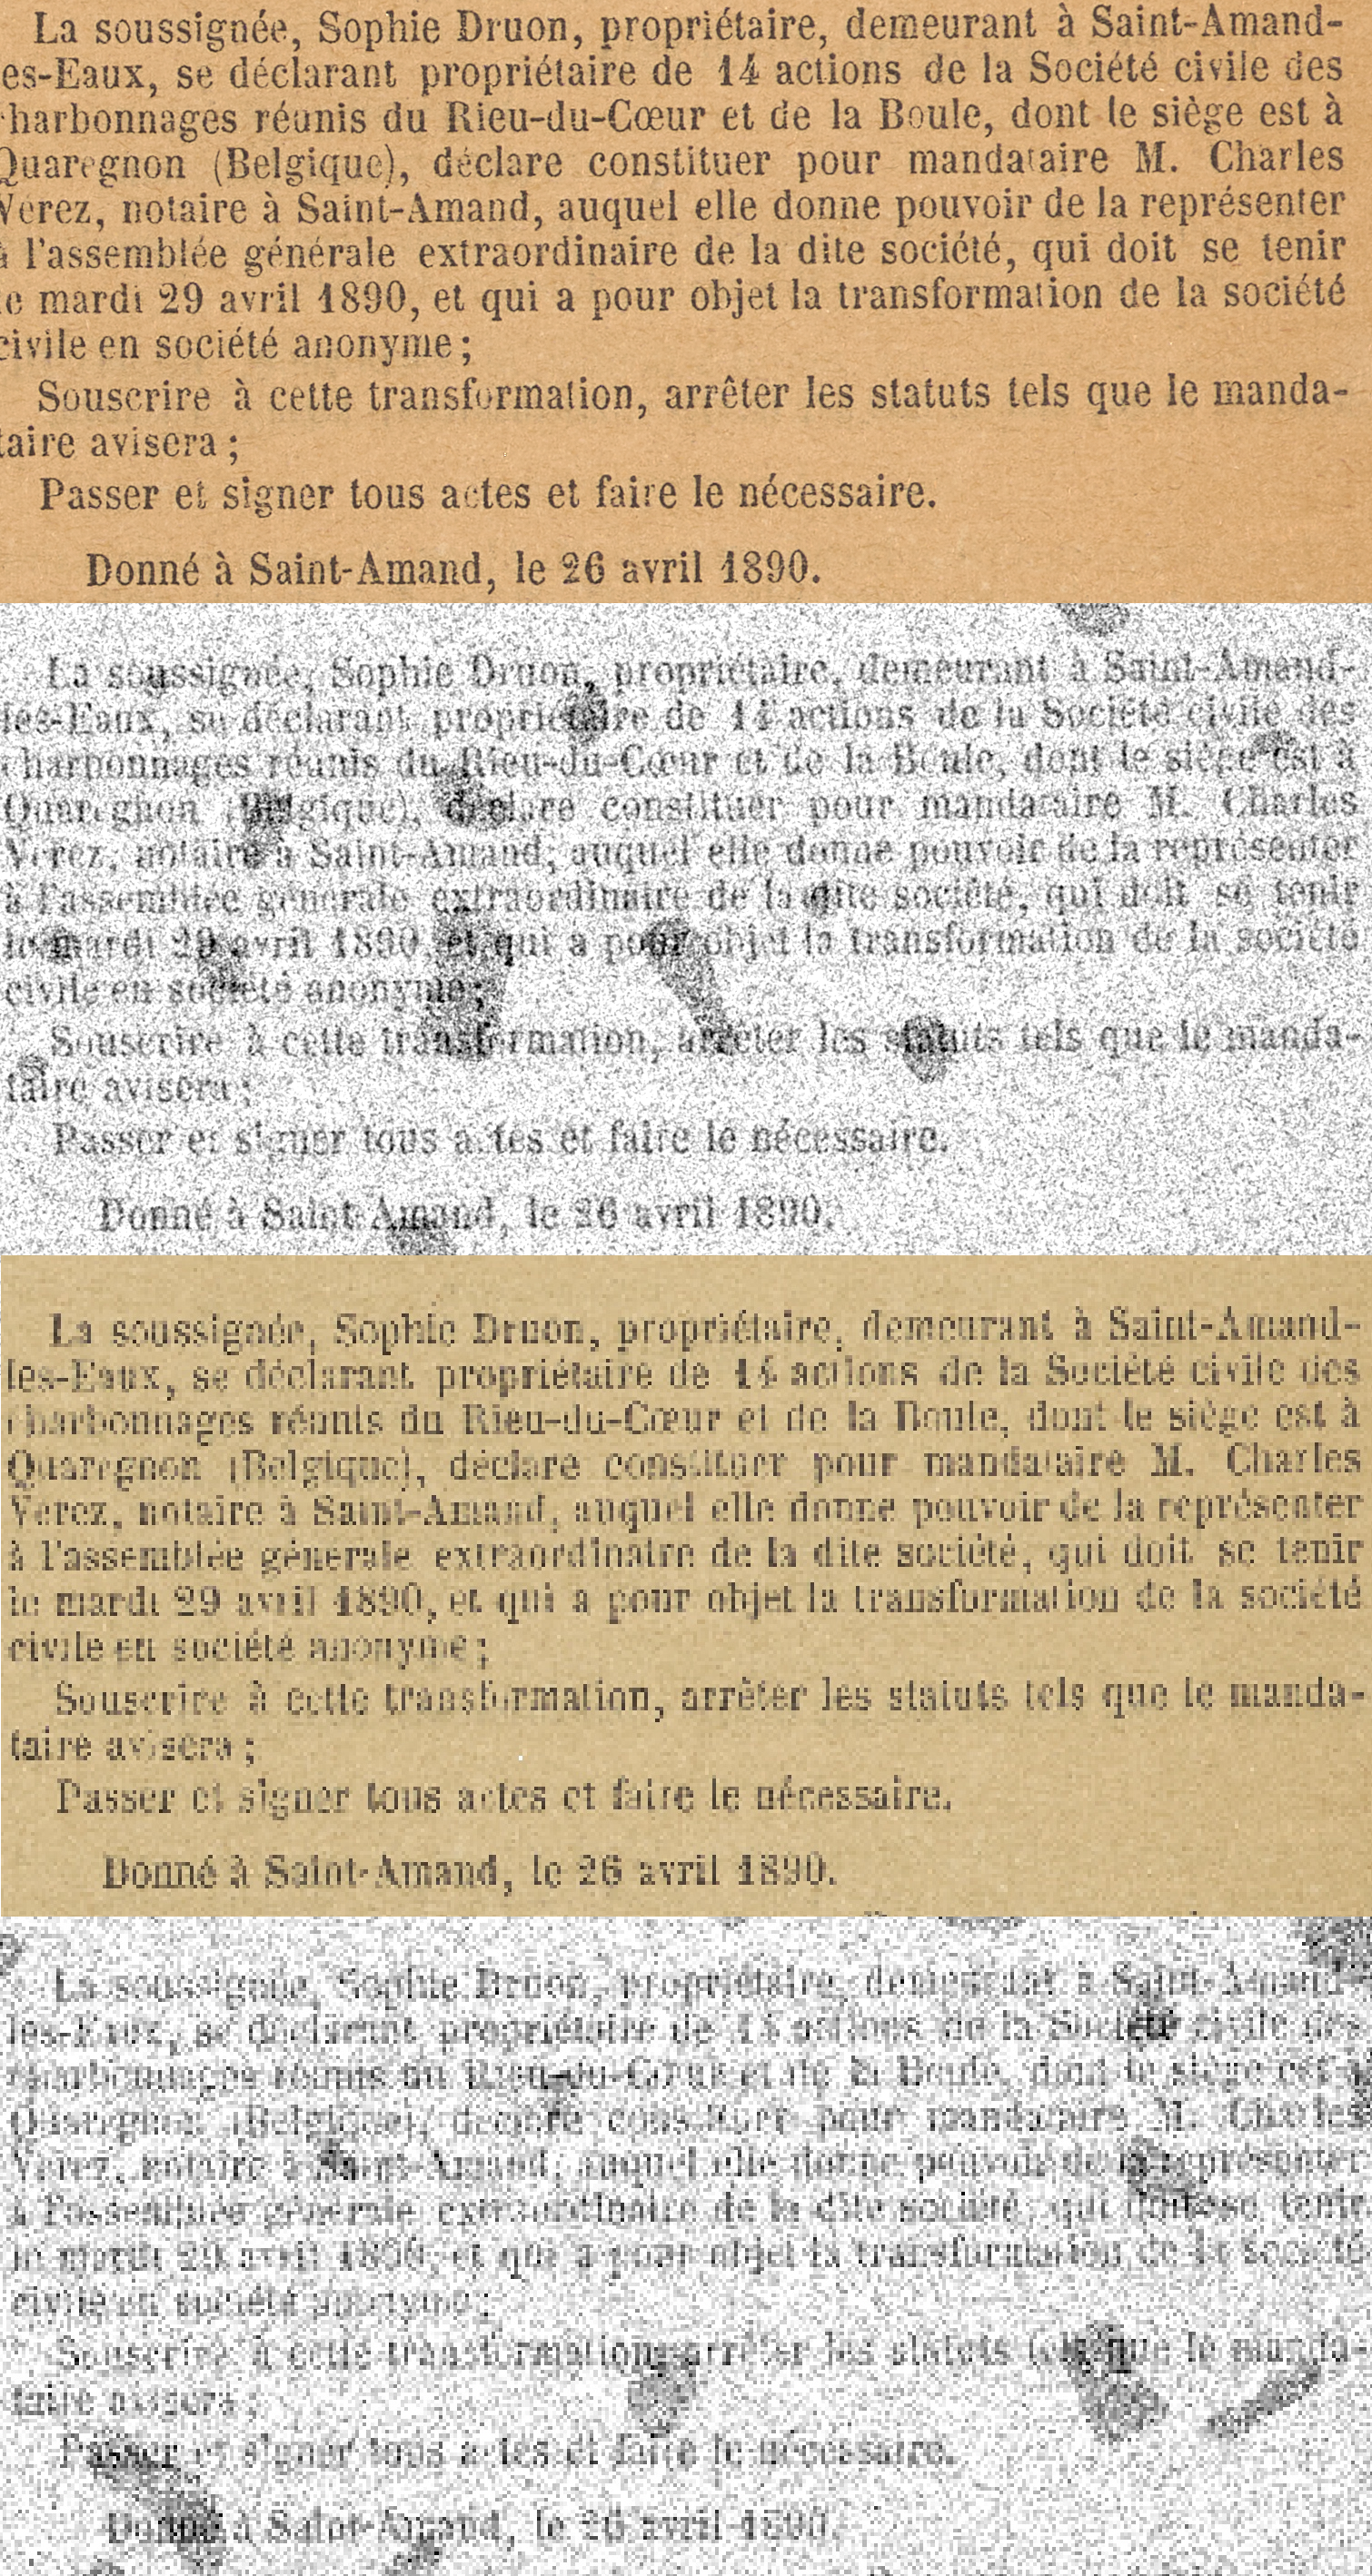

In [8]:
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "An overview of the four image quality tiers (from top to bottom): 'high quality', 'degraded', 'compressed' and 'degraded and compressed.'"
            ]
        }
    }
}

display(Image("media/degradation_overview.png", width=350), metadata=metadata)

The four image quality tiers are defined as follows:

1. High quality: The original, uncompressed 400 ppi images, serving as the baseline for comparison. These correspond to the same line images used in the previous experiment.
2. Degraded: Images subjected to noise addition and Gaussian filtering to emulate ink bleed-through and other forms of visual degradation typical of historical documents.
3. Compressed: Images binarised and subsequently subjected to JPEG compression, reducing extrinsic image quality by introducing compression artefacts.
4. Degraded and compressed: Images exposed to both intrinsic degradation and JPEG compression.

To isolate the effect of image input quality, the textual prompt was held constant across all image quality tiers, with only the visual input being varied. For comparability, we consistently employed the most performant prompt for each model, as identified in the preceding experiment.


In [ ]:
from script.utils import degrade_image, apply_jpeg_compression
from PIL import Image as PILImage

# Load original image
original_image = PILImage.open("script/data/image.tif")
# Quality of the JPEG compressed image
jpeg_quality=30

# Choose which combination to apply: 'degrade', 'compress', or 'both'
choice = 'compress'  # Change this to 'degrade', 'compress', or 'both'

if choice == 'degrade':
    result = degrade_image("script/data/image.tif")
elif choice == 'compress':
    result = apply_jpeg_compression(original_image, jpeg_quality)
elif choice == 'both':
    result = degrade_image("script/data/image.tif")
    result = apply_jpeg_compression(result, jpeg_quality)

result

| Model        | High Quality |        | Degraded |        | Compressed |        | Deg + Compressed |        |
|--------------|--------------|--------|----------|--------|------------|--------|------------------|--------|
|              | CER          | WER    | CER      | WER    | CER        | WER    | CER              | WER    |
| Tesseract    | 7.18         | 18.97  | 23.04    | 60.75  | 23.78      | 52.89  | 23.66            | 59.1   |
| Kraken       | 19.16        | 55.79  | 28.68    | 67.74  | 34.08      | 77.52  | 61.83            | 92.52  |
| TrOCR        | 17.42        | 59.55  | 35.62    | 90.33  | 36.29      | 87.63  | 67.33            | 1.17   |
| CHURRO       | 4.91         | 13.09  | 17.71    | 34.85  | 18.06      | 35.47  | 60.37            | 83.2   |
| Deepseek-OCR | 18.2         | 30.55  | 24.57    | 45.47  | 25.02      | 40.12  | 67.8             | 92.49  |
| Qwen-3-VL    | 2.7          | 10.4   | 5.36     | 18.21  | 4.57       | 16.49  | 23.79            | 44.60  |


Table X shows how different OCR and vision–language models respond to changes in image quality. For traditional ATR systems like Tesseract and Kraken, performance drops sharply when images are degraded or compressed. For example, Tesseract’s CER rises from 7.18% on high-quality images to 23.04% under degradation, and Kraken’s CER increases from 19.16% to 61.83% when degradation and compression are combined. Even compression alone significantly affects performance, with Tesseract’s CER increasing to 23.78% and Kraken’s to 34.08%. TrOCR behaves similarly, despite its transformer-based architecture. Its CER increases from 17.42% on high-quality images to 35.62% when degraded, and 36.29% under compression. Combining both effects pushes the CER to 67.33%, showing that image quality remains a limiting factor even for more advanced models.

Vision–language models show more resilience. For example, Qwen-3-VL maintains a CER of just 2.7% on high-quality images and only rises to 5.36% when degraded, with compression increasing it slightly to 4.57%. Only when degradation and compression are combined does the CER reach 23.79%, still substantially lower than traditional systems like Kraken or Tesseract under the same conditions. Deepseek-OCR shows intermediate performance, with CER rising from 18.2% to 67.8% across the spectrum from high-quality to degraded + compressed images.

Overall, these results show that image quality affects all models, but the impact varies. Traditional systems are highly sensitive to even modest degradation or compression, transformer-based models like TrOCR are moderately affected, and larger vision–language models like Qwen-3-VL are more robust. Still, none are immune: when images are both degraded and compressed, all models experience significant drops in performance. This is particularly relevant for digitized historical documents, where such quality issues are common.

Interpreting VLM performance requires caution, as character recognition and text generation are tightly coupled in these models. Sometimes a VLM produces a correct transcription even when individual characters are visually ambiguous, relying on linguistic or contextual cues. This can create the impression of strong character-level recognition, even when the visual evidence is weak. While this compensatory behavior works well for linguistically structured text, it is less reliable for content with limited context, such as numerical data or tables.


#### Experiment 3: Table understanding

Traditional ATR systems typically separate layout analysis and text extraction into sequential stages. This design allows segmentation errors to propagate and prevents recognition modules from using document-level context. Tables, titles, headings, and text blocks are treated as independent elements, often requiring manual heuristics and format-specific post-processing. These constraints limit robustness, especially for degraded or irregular historical documents. VLMs integrate layout understanding and text recognition in a single inference step. They can directly produce structured outputs such as JSON, Markdown, or XML, preserve contextual relationships, and learn document conventions from data rather than hand-coded rules. This suggests this makes them better suited to the heterogenous layouts and mixed content commonly found in historical sources.

Our evaluation examines whether VLMs can both interpret tables and ground their text predictions, that is, accurately associate extracted text with specific pixel regions or bounding boxes in the source image. While several models generate plausible structured outputs such as JSON or Markdown, most fail to reliably align recognised text with precise spatial coordinates, in contrast to traditional layout-aware ATR systems (<cite id="vn6ch"><a href="#zotero%7C7368571%2FRPV7QCRP">(Xiao et al., 2025)</a></cite>). We observe this limitation in both CHURRO and Qwen-VL. DeepSeek-OCR explicitly targets grounding by incorporating spatial supervision during training, enabling it to anchor recognised text to image regions. However, despite improved localisation at the line or region level, our evaluation shows that DeepSeek-OCR cannot produce structured representations suitable for tabular transcription. Although individual text elements are spatially grounded with bounding boxes, the model does not recover higher-level structures such as columns, row grouping or table heading hierarchies [Figure 4](#anchor-figure-bbox). This indicates that its grounding-oriented training supports image region localisation but does not extend to table understanding.

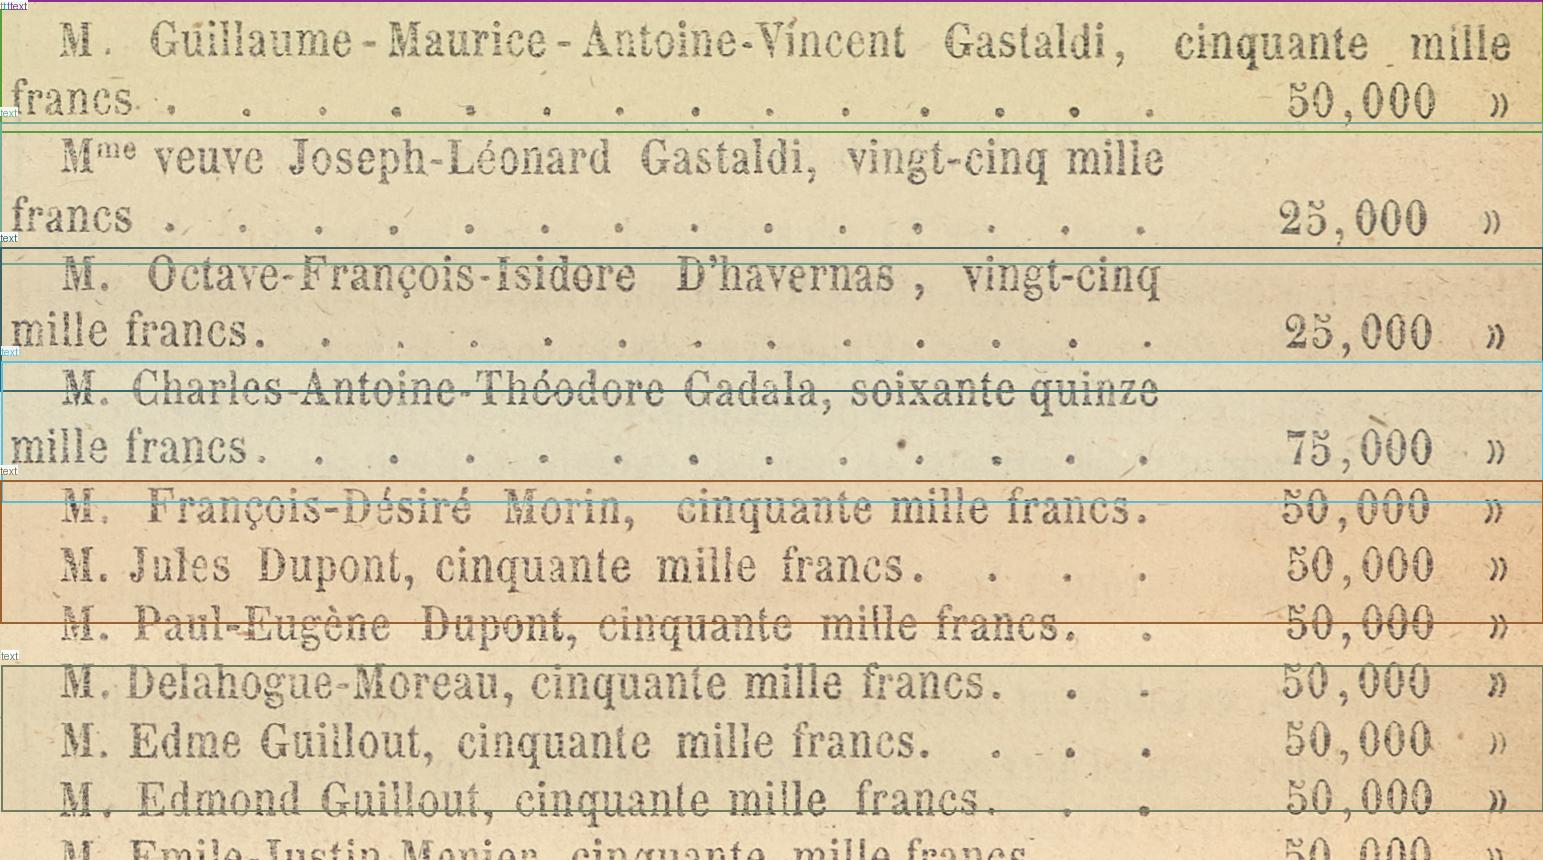

In [10]:
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "DeepSeek-OCR output with “line-level” spatial grounding. Bounding boxes are provided for what the model considers individual text lines, but column boundaries are not recovered, preventing reconstruction of the table’s two-column structure."
            ]
        }
    }
}

display(Image("media/bbox_deepseek.jpg", width=1000), metadata=metadata)

To analyse CHURRO and QWEN-VL further, we apply relevancy mapping during transcription. Relevancy maps for CHURRO reveal a consistent mismatch between the visual regions highlighted by the model and the actual location of the word being transcribed. [Figure 5](#anchor-figure-churro) illustrates this effect using the token *“ine”*, as part of the word *“Usine”*, which appears twice in the table: *“Inventaire du materiel et des immeubles par destination dépendant de l’Usine à canons du Val-Benoit”*. When the first occurrence is transcribed, the relevancy map not only highlights the actual location of the token, but also the region corresponding to the second occurrence. This suggests that the model is not grounding individual tokens to unique spatial instances.

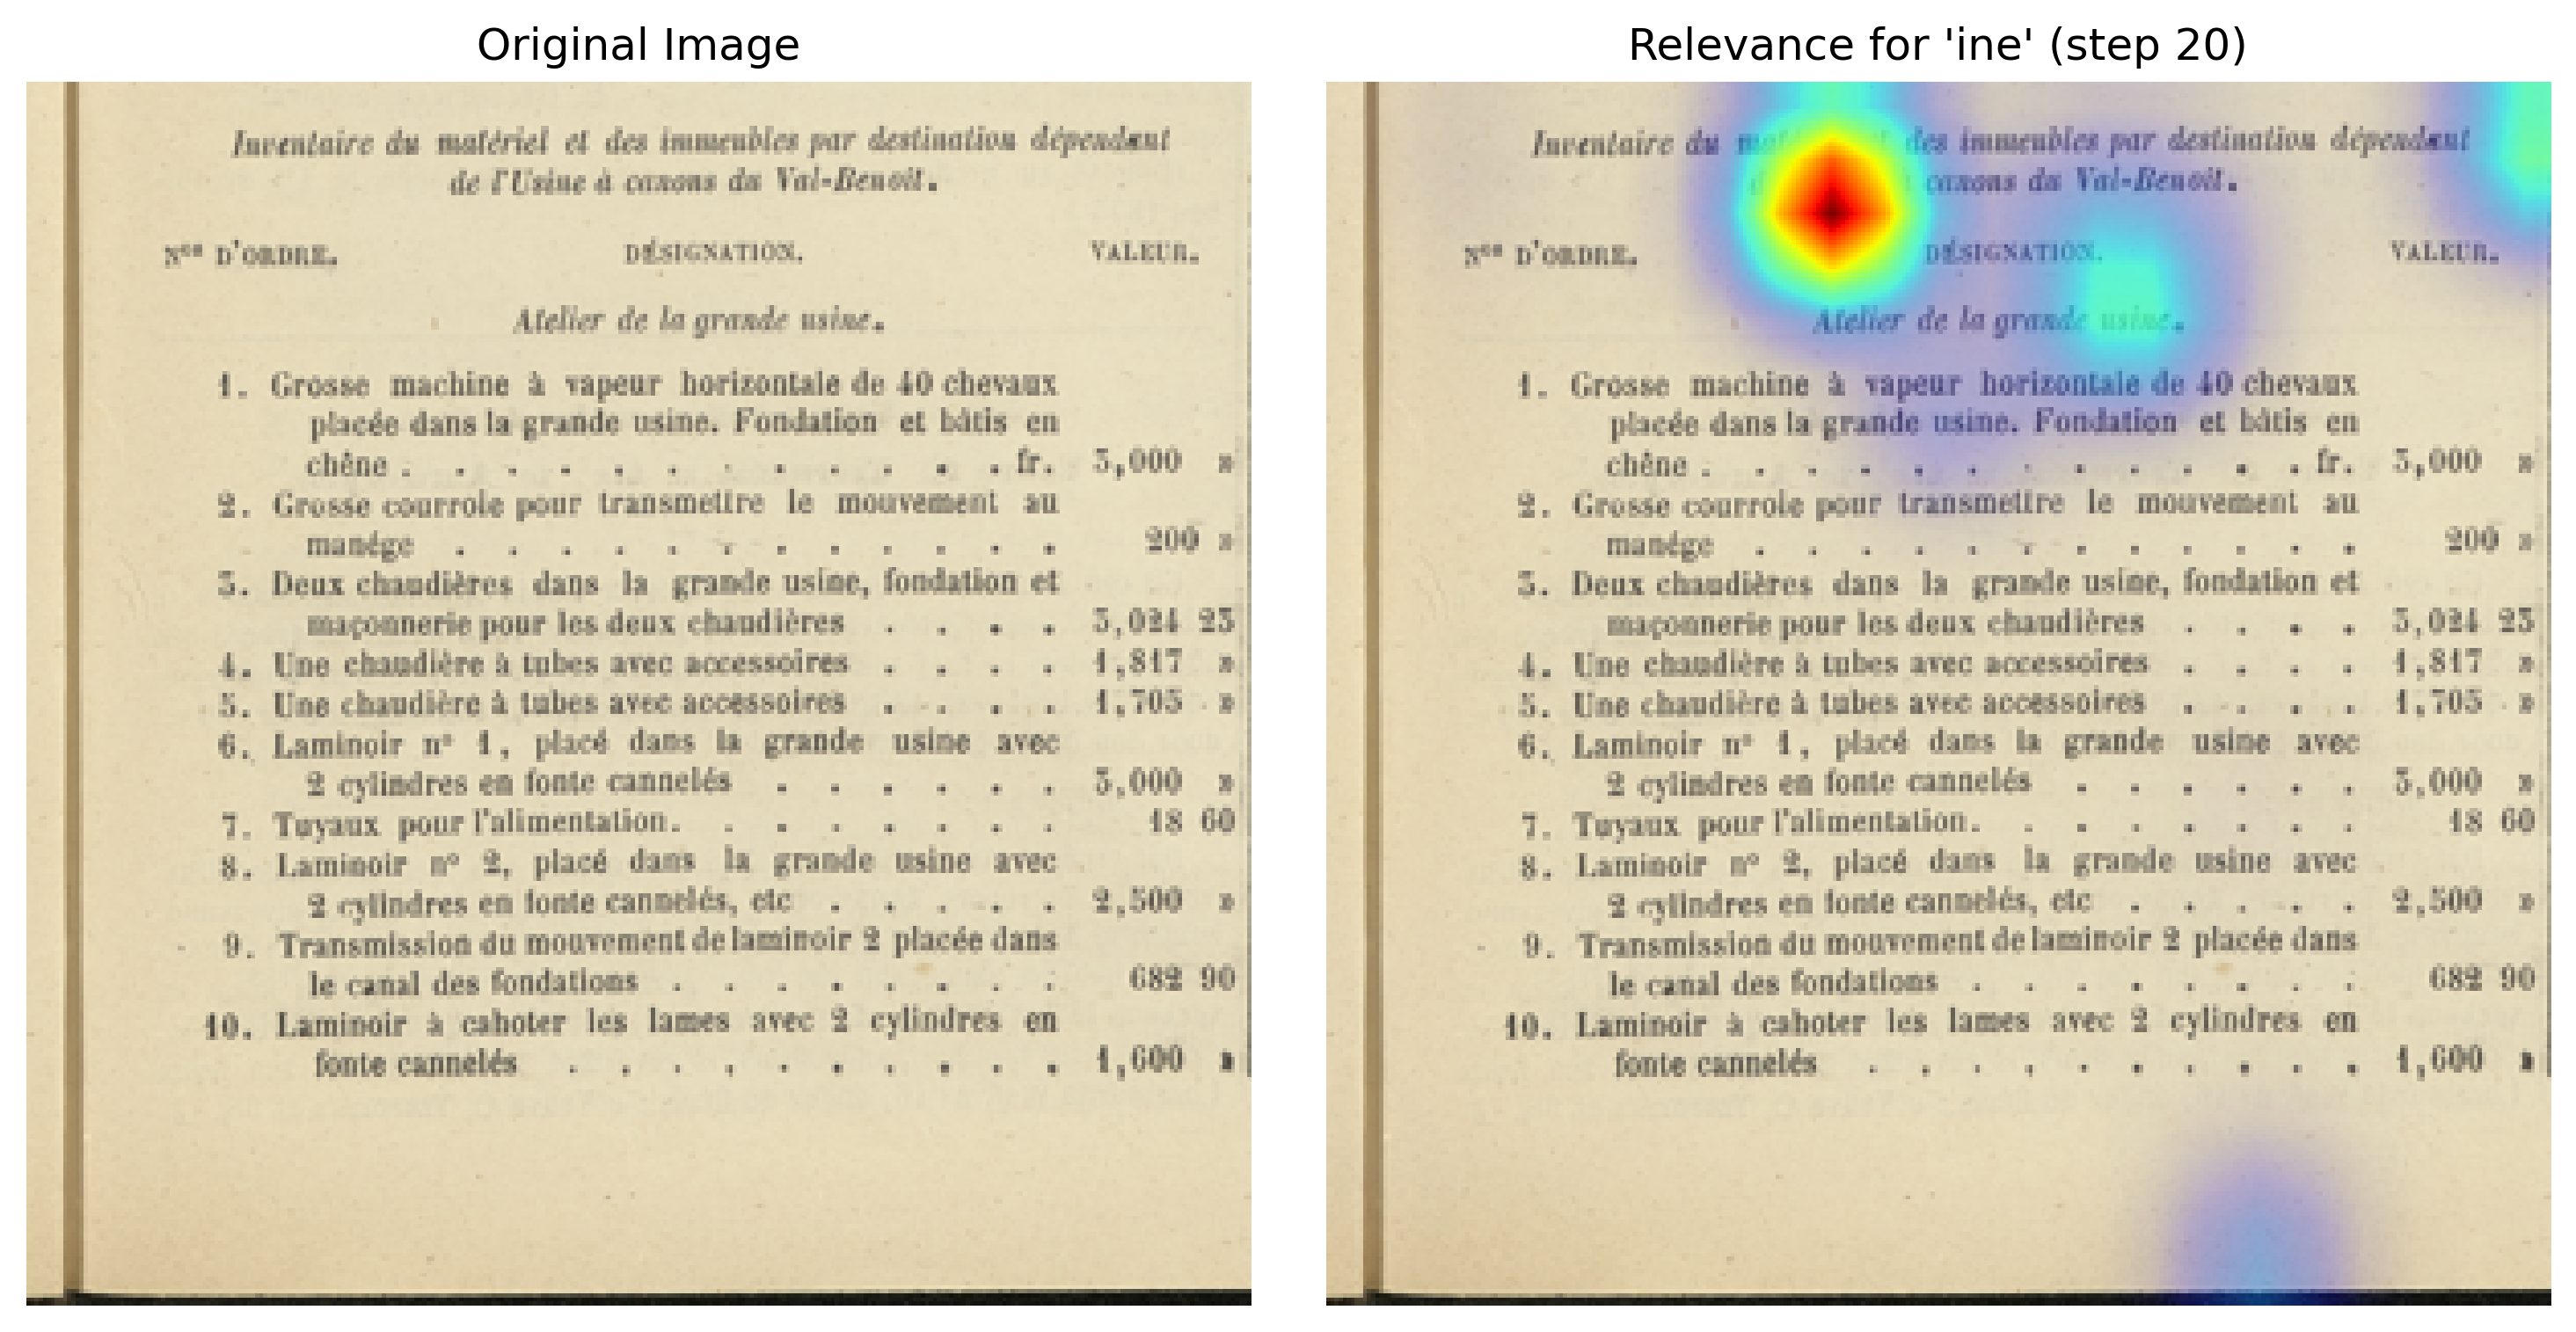

In [15]:
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "relevancy mapping of the token ‘ine’, as part of the word Usine: Here we highlight the token “ine”, which occurs twice in the table: “Inventaire du materiel et des immeubles par destination dépendant de l’Usine à canons du Val-Benoit."
            ]
        }
    }
}

display(Image("media/churro_relevancy_map.png", width=1000), metadata=metadata)

In [ ]:
# Note how step 20, the image that is displayed, is the first step where the token "ine" is generated
!python "script/relevancy_mapping.py" --image_path "script/data/rel_mapping_header.png" --prompt "Transcribe the text in the image." --target_token "ine" --max_new_tokens 75
display(Image('/home/bas/Documents/Visual Code Repos/journal-of-digital-history/script/data/rel_map_output/qwen_lvlm_step020_ine.png'))

A possible explanation for this behaviour is suggested by (<cite id="tqzmq"><a href="#zotero%7C7368571%2FRPV7QCRP">(Xiao et al., 2025)</a></cite>), who argue that many contemporary grounding approaches rely on separately trained visual and language backbones whose feature spaces are only loosely aligned across modalities. This partial alignment can cause semantically similar visual regions to activate in comparable ways, leading to ambiguity when repeated words occur. The same limitation helps explain why general-purpose VLMs such as CHURRO and QWEN-VL struggle with precise bounding-box predictions.

Despite their grounding limitations, VLMs generally produce more robust semantic representations of tables. To quantify this, we conducted a semantic table transcription experiment on 35 tables from our dataset. Each table was converted into an HTML tree and manually validated as ground truth. Models were prompted to transcribe the full table content, including textual and numerical values, and to output structured Markdown or XML format, depending on model capabilities. Performance was evaluated using Tree Edit Distance Similarity (TEDS).

In [ ]:
from script.utils import teds_score
import pandas as pd
from IPython.display import display, HTML

pred = "script/data/table_qwen.html"
truth = "script/data/table_truth.html"

def display_html_section(pred_html_path, truth_html_path, row_start=0, row_end=5):
    pred_table = pd.read_html(pred_html_path)[0]
    truth_table = pd.read_html(truth_html_path)[0]

    pred_section = pred_table.iloc[row_start:row_end].copy()
    truth_section = truth_table.iloc[row_start:row_end].copy()

    pred_section.columns = [f"pred: {c}" for c in pred_section.columns]
    truth_section.columns = [f"truth: {c}" for c in truth_section.columns]

    combined = pd.concat([pred_section.reset_index(drop=True), truth_section.reset_index(drop=True)], axis=1)
    display(HTML(combined.to_html(index=False, escape=False)))

# Example
display_html_section(
    pred,
    truth,
    row_start=0,
    row_end=5
)

print("TEDS score:", teds_score(truth, pred))

| Model Name | TEDS-score |
|------------|------------|
| Qwen3-VL-8B | 0.95       |
| CHURRO     | 0.83      |

Qwen3-VL-8B achieves a high TEDS score, indicating strong performance in capturing both content and structure. CHURRO performs notably worse, not due to inaccurate transcription at the content level, but because it often produces structurally inconsistent outputs that are penalised by tree-based metrics. In many cases, the generated transcriptions remain accurate but fail to conform to a well-formed hierarchical representation.

Overall, these results highlight a trade-off between grounding-oriented ATR models and general-purpose VLMs. Models optimised for spatial grounding excel at localising text but struggle with higher-level structural reasoning. Larger VLMs, while less precise in spatial alignment, demonstrate stronger semantic understanding and are able to reconstruct table hierarchy. Crucially, these findings reinforce that VLMs cannot be treated as a homogenous category: their behaviour varies substantially, an effective implementation requires careful model selection aligned with specific demands of the task.


## Discussion
Our first experiment revealed that prompt design matters, but not always as expected. A basic prompt without additional context generally produced the best results.  Adding linguistic or temporal information degraded performance, particularly in OCR-specific models, though the impact on QWEN-3-VL–the largest general purpose model at 8B parameters–was minimal. Temporal context proved more harmful than linguistic context, but combining both mitigates the adverse effects of the former. Whether temporal cues become more useful for historical ATR when models are trained on more explicitly time-aware data remains an open question worth pursuing.

Image quality played a predictable but important role in our second experiment. Clean, high-resolution images yielded near-perfect transcriptions, while low-quality images caused accuracy to drop sharply. Even so, all VLMs outperformed traditional ATR on poor-quality images, with QWEN-3-VL proving most resilient. This suggests that VLMs remained constrained by their training data, which skews toward modern, web-quality text. Making these models robust to historical document degradation is essential wider applicability.

The third experiment exposed a fundamental tension between spatial grounding and structural understanding. Traditional ATR systems localize text reliably but lack document-level understanding without extensive fine-tuning. VLMs understand complex historical layouts out-of-the-box by modeling text and structure together, yet most struggle to ground words to pixel bounding boxes. DeepSeek-OCR achieves line-level grounding but misses higher-level structures like columns. Qwen3-VL-8B reconstructs the semantics of tables effectively, while CHURRO transcribes accurately but produces inconsistent structure. No single VLM model excels at both grounding and reasoning, so the choice between traditional ATR and VLMs depends on the task at hand.

Across all experiments, model size mattered. Larger VLMs handled visually complex or multilingual sources better, while smaller models like CHURRO delivered competitive results on simpler material at far lower computational cost. This performance-efficiency trade-off offers practical guidance for researchers choosing models. Even larger models (i.e. Qwen3-VL 30B, 235B)  would likely perform even better, but we prioritized accessibility and sustainability by testing models that run on commonly available hardware.

## Conclusion

VLMs represent a fundamental departure from traditional ATR systems. Where tools like Tesseract operate through pattern matching, VLMs integrate visual and linguistic reasoning to interpret documents. This makes them resilient to ambiguous input but also prone to plausible hallucinations. Sometimes they appear to "correct" sources by filling gaps or reconstructing missing words, which complicates how we evaluate their output.

For digital humanities, this creates both opportunities and risks. VLMs can produce high-quality transcriptions without extensive preprocessing or training, lowering barriers to large-scale digitization. But this ease of use can obscure the interpretive work happening behind the scenes. Prompt phrasing and visual context shape results in ways researchers may not notice, potentially influencing outcomes without their awareness. Rather than treating VLMs as black-box replacements for ATR, scholars should approach them as interpretive systems requiring careful documentation. Manual review of hallucinations, open sharing of prompts, and transparent validation steps can make these workflows more accountable and reproducible.

Hallucinations remain especially difficult to detect automatically because semantically plausible errors slip past dictionary checks. This challenges traditional notions of textual fidelity in historical research. Historians prioritize the "truth of the source," but VLMs operate more like editors, applying interpretive logic. Whether this constitutes error or assistance depends on disciplinary norms, making reflexive evaluation protocols essential.

Model transparency matters for scholarly control. Proprietary weights and training data limit critique and replication, which is why we chose open-weight models for this study. Computational access remains uneven too. Large models require hardware many institutions lack, though smaller architectures like CHURRO suggest democratization is possible. Ensuring equitable access to compute and open infrastructure will be crucial to prevent stratification in AI-assisted scholarship.

Our findings indicate two research priorities. First, domain-specific fine-tuning on curated historical corpora could address the prompt sensitivity and generalization limitations identified in our experiments. CHURRO demonstrates that targeted training on historical materials yields substantial performance gains. Second, understanding model decision-making processes requires scalable interpretability methods. Attention visualization and similar techniques become computationally prohibitive for large models processing high-resolution document images. Our prompt-based evaluations and systematic error analyses provide practical alternatives for characterizing model behavior without direct access to internal representations. Developing interpretable frameworks for large-scale VLMs addresses both theoretical questions about multimodal reasoning and practical digitization requirements. Work we will continue pursue through Clariah-VL+.


## Author contributions
BV and VD formulated the research concept, objectives and methodology with the contributions of JB and CV. BV was responsible for the code implementation and result visualisation. BV and VD worked on investigation and formal analysis. BV and VD wrote the original draft, and all authors contributed to draft revision, read, and approved the submitted version. JB and CV contributed to supervision. JA, JP, MD, OG, GV, DC, CV, RD, JB were responsible for the BELHISFIRM project conceptualization and funding acquisition.

## Funding

BelHisFirm is supported by the FWO Research Foundation Flanders through its Large-Scale Research Infrastructure program (2024–2028; Project I015424N) and by CLARIAH-VL+, which advances the development of an SSH Open Science Cloud for Flanders (2025–2028; Project I001525N). Within CLARIAH-VL+, WP5 investigates AI explainability methods and WP2 develops automated workflows for extracting structured data from complex historical documents.

## Acknowledgements

The authors gratefully acknowledge Fien Danniau and Sytze Van Herck (GhentCDH), as well as colleagues at the University of Antwerp for their valuable feedback during the preparation of this article. Special thanks goes to the Hendrik Conscience Heritage Library (Antwerp) for providing access to the Annexes. The authors also thank student assistant Heike Bekaert for contributions to ground-truth preparation and data extraction. The computational resources (Stevin Supercomputer Infrastructure) and services used in this work were provided by the Flemish Supercomputer Center (VSC), funded by Ghent University, Research Foundation Flanders (FWO) and the Flemish Government (department EWI).

#### Footnotes
1. We use Automatic Text Recognition (ATR) to refer to both Optical Character Recognition (OCR) for printed text and Handwritten Text Recognition (HTR). Modern systems, including both traditional tools (e.g., Kraken) and vision-language models, can handle both modalities, making the traditional distinction largely obsolete in contemporary digitization workflows.
2. All code, prompts, and evaluation scripts are available in our public repository [URL to be added upon publication]. The corpus and ground-truth annotations will be released under a CC BY 4.0 license.
3. See https://onlinebooks.library.upenn.edu/webbin/serial?id=recspcombe 
4. https://ocr-d.de/en/spec/ocrd_eval.html


## Bibliography

<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="zotero|7368571/WBY8WWKM"></i>Adam, S., Annaert, J., Buelens, F., Coüasnon, B. B., Cule, B., de Vicq, A., Guerry, C., Hautcoeur, P.-C., Paquet, T., Camacho, A. R., Le Floch, I., Lemaitre, A., Karapanagiotis, P., Poukens, J., &#38; Riva, A. (2021, December). Data extraction and matching The EurHisFirm experience. <i>Methodological Advances in the Extraction and Analysis of Historical Data</i>. <a href="https://hal.science/hal-03828381">https://hal.science/hal-03828381</a></div>
  <div class="csl-entry"><i id="zotero|7368571/62Q4CU9K"></i>Aflalo, E., Du, M., Tseng, S.-Y., Liu, Y., Wu, C., Duan, N., &#38; Lal, V. (2022). <i>VL-InterpreT: An Interactive Visualization Tool for Interpreting Vision-Language Transformers</i> (arXiv:2203.17247). arXiv. <a href="https://doi.org/10.48550/arXiv.2203.17247">https://doi.org/10.48550/arXiv.2203.17247</a></div>
  <div class="csl-entry"><i id="zotero|7368571/PA9U9L5K"></i>Ahuja, K., Diddee, H., Hada, R., Ochieng, M., Ramesh, K., Jain, P., Nambi, A., Ganu, T., Segal, S., Axmed, M., Bali, K., &#38; Sitaram, S. (2023). <i>MEGA: Multilingual Evaluation of Generative AI</i> (arXiv:2303.12528). arXiv. <a href="https://doi.org/10.48550/arXiv.2303.12528">https://doi.org/10.48550/arXiv.2303.12528</a></div>
  <div class="csl-entry"><i id="zotero|7368571/P42LQNMN"></i>Alalaq, A. S. (2024). The History of the Artificial Intelligence Revolution and the Nature of Generative AI Work. <i>DS Journal of Artificial Intelligence and Robotics</i>, <i>2</i>(4), 1–24. <a href="https://doi.org/10.59232/AIR-V2I4P101">https://doi.org/10.59232/AIR-V2I4P101</a></div>
  <div class="csl-entry"><i id="zotero|7368571/QTBNFV66"></i>Annaert, J., Buelens, F., &#38; Angelo, R. (2016). Financial History Databases: Old Data, Old Issues, New Insights? In D. Chambers &#38; E. Dimson (Eds.), <i>Financial Market History: Reflections on the Past for Investors Today</i>. Research Foundation Publications. <a href="https://shs.hal.science/halshs-01509708">https://shs.hal.science/halshs-01509708</a></div>
  <div class="csl-entry"><i id="zotero|7368571/HQ3WKAKC"></i>Bäcker-Peral, V., Meursault, V., &#38; Severen, C. (2025). <i>Can LLMs Credibly Transform the Creation of Panel Data from Diverse Historical Tables?</i> (arXiv:2505.11599). arXiv. <a href="https://doi.org/10.48550/arXiv.2505.11599">https://doi.org/10.48550/arXiv.2505.11599</a></div>
  <div class="csl-entry"><i id="zotero|7368571/37AF8D2B"></i>Baek, I., Chang, H., Ryu, S., &#38; Lee, H. (2025). <i>How Do Large Vision-Language Models See Text in Image? Unveiling the Distinctive Role of OCR Heads</i> (arXiv:2505.15865). arXiv. <a href="https://doi.org/10.48550/arXiv.2505.15865">https://doi.org/10.48550/arXiv.2505.15865</a></div>
  <div class="csl-entry"><i id="zotero|7368571/ZUVKVRKX"></i>Bai, Z., Wang, P., Xiao, T., He, T., Han, Z., Zhang, Z., &#38; Shou, M. Z. (2024). <i>Hallucination of Multimodal Large Language Models: A Survey</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2404.18930">https://doi.org/10.48550/ARXIV.2404.18930</a></div>
  <div class="csl-entry"><i id="zotero|7368571/FM8KLSP9"></i>Baltrusaitis, T., Ahuja, C., &#38; Morency, L.-P. (2019). Multimodal Machine Learning: A Survey and Taxonomy. <i>IEEE Transactions on Pattern Analysis and Machine Intelligence</i>, <i>41</i>(2), 423–443. <a href="https://doi.org/10.1109/TPAMI.2018.2798607">https://doi.org/10.1109/TPAMI.2018.2798607</a></div>
  <div class="csl-entry"><i id="zotero|7368571/4NAU5CJA"></i>Bassil, Y., &#38; Alwani, M. (2012). <i>OCR Post-Processing Error Correction Algorithm using Google Online Spelling Suggestion</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.1204.0191">https://doi.org/10.48550/ARXIV.1204.0191</a></div>
  <div class="csl-entry"><i id="zotero|7368571/V9XXI237"></i>Bhardwaj, R., Kumari, S., Jacob, J. J., &#38; Kamra, A. (2025). Enhancing OCR for Historical Documents Using CNNs and GenAI. In R. P. Mahapatra, R. Singh, S. Mishra, &#38; S. Gupta (Eds.), <i>Micro-electronics and Telecommunication Engineering</i> (Vol. 1417, pp. 257–275). Springer Nature Singapore. <a href="https://doi.org/10.1007/978-981-96-6515-0_19">https://doi.org/10.1007/978-981-96-6515-0_19</a></div>
  <div class="csl-entry"><i id="zotero|7368571/FC7E99KQ"></i>Boros, E., Ehrmann, M., Romanello, M., Najem-Meyer, S., &#38; Kaplan, F. (2024). Post-Correction of Historical Text Transcripts with Large Language Models: An Exploratory Study. In Y. Bizzoni, S. Degaetano-Ortlieb, A. Kazantseva, &#38; S. Szpakowicz (Eds.), <i>Proceedings of the 8th Joint SIGHUM Workshop on Computational Linguistics for Cultural Heritage, Social Sciences, Humanities and Literature (LaTeCH-CLfL 2024)</i> (pp. 133–159). Association for Computational Linguistics. <a href="https://aclanthology.org/2024.latechclfl-1.14/">https://aclanthology.org/2024.latechclfl-1.14/</a></div>
  <div class="csl-entry"><i id="zotero|7368571/BDHQ3Y3N"></i>Bourne, J. (2025). <i>CLOCR-C: Context Leveraging OCR Correction with Pre-trained Language Models</i> (arXiv:2408.17428). arXiv. <a href="https://doi.org/10.48550/arXiv.2408.17428">https://doi.org/10.48550/arXiv.2408.17428</a></div>
  <div class="csl-entry"><i id="zotero|7368571/PXIH944A"></i>Brown, T. B., Mann, B., Ryder, N., Subbiah, M., Kaplan, J., Dhariwal, P., Neelakantan, A., Shyam, P., Sastry, G., Askell, A., Agarwal, S., Herbert-Voss, A., Krueger, G., Henighan, T., Child, R., Ramesh, A., Ziegler, D. M., Wu, J., Winter, C., … Amodei, D. (2020). <i>Language Models are Few-Shot Learners</i> (arXiv:2005.14165). arXiv. <a href="https://doi.org/10.48550/arXiv.2005.14165">https://doi.org/10.48550/arXiv.2005.14165</a></div>
  <div class="csl-entry"><i id="zotero|7368571/RIFNQ4EL"></i>Chang, K. K., Cramer, M., Soni, S., &#38; Bamman, D. (2023). <i>Speak, Memory: An Archaeology of Books Known to ChatGPT/GPT-4</i> (arXiv:2305.00118). arXiv. <a href="https://doi.org/10.48550/arXiv.2305.00118">https://doi.org/10.48550/arXiv.2305.00118</a></div>
  <div class="csl-entry"><i id="zotero|7368571/R9G9B3XJ"></i>Chen, L., Zhao, H., Liu, T., Bai, S., Lin, J., Zhou, C., &#38; Chang, B. (2025). An Image is Worth 1/2 Tokens After Layer 2: Plug-and-Play Inference Acceleration for Large Vision-Language Models. In A. Leonardis, E. Ricci, S. Roth, O. Russakovsky, T. Sattler, &#38; G. Varol (Eds.), <i>Computer Vision – ECCV 2024</i> (pp. 19–35). Springer Nature Switzerland. <a href="https://doi.org/10.1007/978-3-031-73004-7_2">https://doi.org/10.1007/978-3-031-73004-7_2</a></div>
  <div class="csl-entry"><i id="zotero|7368571/XU42E3Y9"></i>Correia, S., &#38; Luck, S. (2023). Digitizing historical balance sheet data: A practitioner’s guide. <i>Explorations in Economic History</i>, <i>87</i>, 101475. <a href="https://doi.org/10.1016/j.eeh.2022.101475">https://doi.org/10.1016/j.eeh.2022.101475</a></div>
  <div class="csl-entry"><i id="zotero|7368571/I4RX3CRK"></i>Crosilla, G., Klic, L., &#38; Colavizza, G. (2025). Benchmarking large language models for handwritten text recognition. <i>Journal of Documentation</i>, <i>81</i>(7), 334–354. <a href="https://doi.org/10.1108/JD-03-2025-0082">https://doi.org/10.1108/JD-03-2025-0082</a></div>
  <div class="csl-entry"><i id="zotero|7368571/D6TP7XYU"></i>Cui, C., Zhou, Y., Yang, X., Wu, S., Zhang, L., Zou, J., &#38; Yao, H. (2023). <i>Holistic Analysis of Hallucination in GPT-4V(ision): Bias and Interference Challenges</i> (arXiv:2311.03287). arXiv. <a href="https://doi.org/10.48550/arXiv.2311.03287">https://doi.org/10.48550/arXiv.2311.03287</a></div>
  <div class="csl-entry"><i id="zotero|7368571/TC5YN5WB"></i>Dell, M. (2024). <i>Deep Learning for Economists</i> (arXiv:2407.15339). arXiv. <a href="https://doi.org/10.48550/arXiv.2407.15339">https://doi.org/10.48550/arXiv.2407.15339</a></div>
  <div class="csl-entry"><i id="zotero|7368571/2QMKHXB2"></i>Dong, L., &#38; Crisan, A. (n.d.). <i>Probing the Visualization Literacy of Vision Language Models: the Good, the Bad, and the Ugly</i>.</div>
  <div class="csl-entry"><i id="zotero|7368571/4VKHJEL2"></i>Ducros, J., Grandi, E., Hékimian, R., Prunaux, E., Riva, A., &#38; Ungaro, S. (2018). Collecting and storing historical financial data : the DFIH project. <i>PSE-Ecole d’économie de Paris (Postprint)</i>. <a href="https://ideas.repec.org//p/hal/pseptp/halshs-01884372.html">https://ideas.repec.org//p/hal/pseptp/halshs-01884372.html</a></div>
  <div class="csl-entry"><i id="zotero|7368571/YDT5NSKF"></i>Eriksson, M., Purificato, E., Noroozian, A., Vinagre, J., Chaslot, G., Gomez, E., &#38; Fernandez-Llorca, D. (2025). <i>Can We Trust AI Benchmarks? An Interdisciplinary Review of Current Issues in AI Evaluation</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2502.06559">https://doi.org/10.48550/ARXIV.2502.06559</a></div>
  <div class="csl-entry"><i id="zotero|7368571/HWSSUQH4"></i>Favero, A., Zancato, L., Trager, M., Choudhary, S., Perera, P., Achille, A., Swaminathan, A., &#38; Soatto, S. (2024). <i>Multi-Modal Hallucination Control by Visual Information Grounding</i> (arXiv:2403.14003). arXiv. <a href="https://doi.org/10.48550/arXiv.2403.14003">https://doi.org/10.48550/arXiv.2403.14003</a></div>
  <div class="csl-entry"><i id="zotero|7368571/IFSKN8VV"></i>Fleischhacker, D., Kern, R., &#38; Göderle, W. (2025). Enhancing OCR in historical documents with complex layouts through machine learning. <i>International Journal on Digital Libraries</i>, <i>26</i>(1), 3. <a href="https://doi.org/10.1007/s00799-025-00413-z">https://doi.org/10.1007/s00799-025-00413-z</a></div>
  <div class="csl-entry"><i id="zotero|7368571/3XU5M463"></i>Fu, J., Ng, S.-K., &#38; Liu, P. (2022). <i>Polyglot Prompt: Multilingual Multitask PrompTraining</i> (arXiv:2204.14264). arXiv. <a href="https://doi.org/10.48550/arXiv.2204.14264">https://doi.org/10.48550/arXiv.2204.14264</a></div>
  <div class="csl-entry"><i id="zotero|7368571/XTF8IQKS"></i>Fu, L., Kuang, Z., Song, J., Huang, M., Yang, B., Li, Y., Zhu, L., Luo, Q., Wang, X., Lu, H., Li, Z., Tang, G., Shan, B., Lin, C., Liu, Q., Wu, B., Feng, H., Liu, H., Huang, C., … Bai, X. (2025). <i>OCRBench v2: An Improved Benchmark for Evaluating Large Multimodal Models on Visual Text Localization and Reasoning</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2501.00321">https://doi.org/10.48550/ARXIV.2501.00321</a></div>
  <div class="csl-entry"><i id="zotero|7368571/3C8KWK9T"></i>Gao, T., Fisch, A., &#38; Chen, D. (2021). <i>Making Pre-trained Language Models Better Few-shot Learners</i> (arXiv:2012.15723). arXiv. <a href="https://doi.org/10.48550/arXiv.2012.15723">https://doi.org/10.48550/arXiv.2012.15723</a></div>
  <div class="csl-entry"><i id="zotero|7368571/IZQEB39J"></i>Ghiriti, A., Göderle, W., &#38; Kern, R. (2024). Exploring the Capabilities of GPT4-Vision as OCR Engine. In A. Antonacopoulos, A. Hinze, B. Piwowarski, M. Coustaty, G. M. Di Nunzio, F. Gelati, &#38; N. Vanderschantz (Eds.), <i>Linking Theory and Practice of Digital Libraries</i> (Vol. 15178, pp. 3–12). Springer Nature Switzerland. <a href="https://doi.org/10.1007/978-3-031-72440-4_1">https://doi.org/10.1007/978-3-031-72440-4_1</a></div>
  <div class="csl-entry"><i id="zotero|7368571/LRTAJ9MP"></i>Gram, D., Karapanagiotis, P., Liebald, M., &#38; Walz, U. (2022). Design and Implementation of a Historical German Firm-level Financial Database. <i>J. Data and Information Quality</i>, <i>14</i>(3), 19:1-19:22. <a href="https://doi.org/10.1145/3531533">https://doi.org/10.1145/3531533</a></div>
  <div class="csl-entry"><i id="zotero|7368571/CR3MFGJB"></i>Greif, G., Griesshaber, N., &#38; Greif, R. (2025). <i>Multimodal LLMs for OCR, OCR Post-Correction, and Named Entity Recognition in Historical Documents</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2504.00414">https://doi.org/10.48550/ARXIV.2504.00414</a></div>
  <div class="csl-entry"><i id="zotero|7368571/Z9Z5F2Y3"></i>Gu, J., Han, Z., Chen, S., Beirami, A., He, B., Zhang, G., Liao, R., Qin, Y., Tresp, V., &#38; Torr, P. (2023). <i>A Systematic Survey of Prompt Engineering on Vision-Language Foundation Models</i> (arXiv:2307.12980). arXiv. <a href="https://doi.org/10.48550/arXiv.2307.12980">https://doi.org/10.48550/arXiv.2307.12980</a></div>
  <div class="csl-entry"><i id="zotero|7368571/KQ4ASD5H"></i>He, Z., Zhang, C., Wu, Z., Chen, Z., Zhan, Y., Li, Y., Zhang, Z., Wang, X., &#38; Qiu, M. (2025). <i>Seeing is Believing? Mitigating OCR Hallucinations in Multimodal Large Language Models</i> (arXiv:2506.20168). arXiv. <a href="https://doi.org/10.48550/arXiv.2506.20168">https://doi.org/10.48550/arXiv.2506.20168</a></div>
  <div class="csl-entry"><i id="zotero|7368571/VJILK7TN"></i>Humphries, M., Leddy, L. C., Downton, Q., Legace, M., McConnell, J., Murray, I., &#38; Spence, E. (2025). Unlocking the archives: Using large language models to transcribe handwritten historical documents. <i>Historical Methods: A Journal of Quantitative and Interdisciplinary History</i>, <i>58</i>(3), 175–193. <a href="https://doi.org/10.1080/01615440.2025.2500309">https://doi.org/10.1080/01615440.2025.2500309</a></div>
  <div class="csl-entry"><i id="zotero|7368571/LXR8Q7CA"></i>Inoue, K. (2025). <i>Context-Independent OCR with Multimodal LLMs: Effects of Image Resolution and Visual Complexity</i> (arXiv:2503.23667). arXiv. <a href="https://doi.org/10.48550/arXiv.2503.23667">https://doi.org/10.48550/arXiv.2503.23667</a></div>
  <div class="csl-entry"><i id="zotero|7368571/8QN6U8XA"></i>Jaillant, L., &#38; Caputo, A. (2022). Unlocking digital archives: cross-disciplinary perspectives on AI and born-digital data. <i>AI &#38; SOCIETY</i>, <i>37</i>(3), 823–835. <a href="https://doi.org/10.1007/s00146-021-01367-x">https://doi.org/10.1007/s00146-021-01367-x</a></div>
  <div class="csl-entry"><i id="zotero|7368571/ZXQJD4QD"></i>Jaillant, L., &#38; Rees, A. (2023). Applying AI to digital archives: trust, collaboration and shared professional ethics. <i>Digital Scholarship in the Humanities</i>, <i>38</i>(2), 571–585. <a href="https://doi.org/10.1093/llc/fqac073">https://doi.org/10.1093/llc/fqac073</a></div>
  <div class="csl-entry"><i id="zotero|7368571/I64ZHCQT"></i>Jain, S., &#38; Wallace, B. C. (2019). <i>Attention is not Explanation</i> (arXiv:1902.10186). arXiv. <a href="https://doi.org/10.48550/arXiv.1902.10186">https://doi.org/10.48550/arXiv.1902.10186</a></div>
  <div class="csl-entry"><i id="zotero|7368571/6TX2ANB3"></i>Ji, Z., Lee, N., Frieske, R., Yu, T., Su, D., Xu, Y., Ishii, E., Bang, Y. J., Madotto, A., &#38; Fung, P. (2023). Survey of Hallucination in Natural Language Generation. <i>ACM Comput. Surv.</i>, <i>55</i>(12), 248:1-248:38. <a href="https://doi.org/10.1145/3571730">https://doi.org/10.1145/3571730</a></div>
  <div class="csl-entry"><i id="zotero|7368571/3FEBWEZM"></i>Kahle, P., Colutto, S., Hackl, G., &#38; Muhlberger, G. (2017). Transkribus - A Service Platform for Transcription, Recognition and Retrieval of Historical Documents. <i>2017 14th IAPR International Conference on Document Analysis and Recognition (ICDAR)</i>, 19–24. <a href="https://doi.org/10.1109/ICDAR.2017.307">https://doi.org/10.1109/ICDAR.2017.307</a></div>
  <div class="csl-entry"><i id="zotero|7368571/JAHGQNRY"></i>Kalai, A. T., Nachum, O., Vempala, S. S., &#38; Zhang, E. (2025). <i>Why Language Models Hallucinate</i> (arXiv:2509.04664). arXiv. <a href="https://doi.org/10.48550/arXiv.2509.04664">https://doi.org/10.48550/arXiv.2509.04664</a></div>
  <div class="csl-entry"><i id="zotero|7368571/NZRG4YE8"></i>Kanerva, J., Ledins, C., Käpyaho, S., &#38; Ginter, F. (2025). <i>OCR Error Post-Correction with LLMs in Historical Documents: No Free Lunches</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2502.01205">https://doi.org/10.48550/ARXIV.2502.01205</a></div>
  <div class="csl-entry"><i id="zotero|7368571/NF5VIQJD"></i>Kang, S., Kim, J., Kim, J., &#38; Hwang, S. J. (2025). <i>See What You Are Told: Visual Attention Sink in Large Multimodal Models</i> (arXiv:2503.03321). arXiv. <a href="https://doi.org/10.48550/arXiv.2503.03321">https://doi.org/10.48550/arXiv.2503.03321</a></div>
  <div class="csl-entry"><i id="zotero|7368571/N43BP6RB"></i>Kiessling, B. (2026). Version 5 of the Kraken ATR Engine for the Humanities. In X.-C. Yin, D. Karatzas, &#38; D. Lopresti (Eds.), <i>Document Analysis and Recognition – ICDAR 2025</i> (pp. 443–458). Springer Nature Switzerland. <a href="https://doi.org/10.1007/978-3-032-04624-6_26">https://doi.org/10.1007/978-3-032-04624-6_26</a></div>
  <div class="csl-entry"><i id="zotero|7368571/ASQIFTJ3"></i>Kiessling, B., Tissot, R., Stokes, P., &#38; Stokl Ben Ezra, D. (2019). eScriptorium: An Open Source Platform for Historical Document Analysis. <i>2019 International Conference on Document Analysis and Recognition Workshops (ICDARW)</i>, 19–19. <a href="https://doi.org/10.1109/ICDARW.2019.10032">https://doi.org/10.1109/ICDARW.2019.10032</a></div>
  <div class="csl-entry"><i id="zotero|7368571/MBB3ITMW"></i>Kim, S., Baudru, J., Ryckbosch, W., Bersini, H., &#38; Ginis, V. (2025). <i>Early evidence of how LLMs outperform traditional systems on OCR/HTR tasks for historical records</i> (arXiv:2501.11623). arXiv. <a href="https://doi.org/10.48550/arXiv.2501.11623">https://doi.org/10.48550/arXiv.2501.11623</a></div>
  <div class="csl-entry"><i id="zotero|7368571/UH9PVFCW"></i>Lee, K., Kim, M., Yoon, S., Kim, M., Lee, D., Koh, H., &#38; Jung, K. (2025). <i>VLind-Bench: Measuring Language Priors in Large Vision-Language Models</i> (arXiv:2406.08702). arXiv. <a href="https://doi.org/10.48550/arXiv.2406.08702">https://doi.org/10.48550/arXiv.2406.08702</a></div>
  <div class="csl-entry"><i id="zotero|7368571/T3PSIMRW"></i>Leng, S., Zhang, H., Chen, G., Li, X., Lu, S., Miao, C., &#38; Bing, L. (2023). <i>Mitigating Object Hallucinations in Large Vision-Language Models through Visual Contrastive Decoding</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2311.16922">https://doi.org/10.48550/ARXIV.2311.16922</a></div>
  <div class="csl-entry"><i id="zotero|7368571/YBDDLPAP"></i>Levchenko, M. (2025). <i>Evaluating LLMs for Historical Document OCR: A Methodological Framework for Digital Humanities</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2510.06743">https://doi.org/10.48550/ARXIV.2510.06743</a></div>
  <div class="csl-entry"><i id="zotero|7368571/RJXRDCUF"></i>Li, M., Cui, L., Huang, S., Wei, F., Zhou, M., &#38; Li, Z. (2020). <i>TableBank: A Benchmark Dataset for Table Detection and Recognition</i> (arXiv:1903.01949). arXiv. <a href="https://doi.org/10.48550/arXiv.1903.01949">https://doi.org/10.48550/arXiv.1903.01949</a></div>
  <div class="csl-entry"><i id="zotero|7368571/SF3DVF42"></i>Li, M., Lv, T., Chen, J., Cui, L., Lu, Y., Florencio, D., Zhang, C., Li, Z., &#38; Wei, F. (2023). TrOCR: Transformer-Based Optical Character Recognition with Pre-trained Models. <i>Proceedings of the AAAI Conference on Artificial Intelligence</i>, <i>37</i>(11), 13094–13102. <a href="https://doi.org/10.1609/aaai.v37i11.26538">https://doi.org/10.1609/aaai.v37i11.26538</a></div>
  <div class="csl-entry"><i id="zotero|7368571/K87K56ID"></i>Lin, X. V., Mihaylov, T., Artetxe, M., Wang, T., Chen, S., Simig, D., Ott, M., Goyal, N., Bhosale, S., Du, J., Pasunuru, R., Shleifer, S., Koura, P. S., Chaudhary, V., O’Horo, B., Wang, J., Zettlemoyer, L., Kozareva, Z., Diab, M., … Li, X. (2022). Few-shot Learning with Multilingual Generative Language Models. In Y. Goldberg, Z. Kozareva, &#38; Y. Zhang (Eds.), <i>Proceedings of the 2022 Conference on Empirical Methods in Natural Language Processing</i> (pp. 9019–9052). Association for Computational Linguistics. <a href="https://doi.org/10.18653/v1/2022.emnlp-main.616">https://doi.org/10.18653/v1/2022.emnlp-main.616</a></div>
  <div class="csl-entry"><i id="zotero|7368571/FUMTAW54"></i>Lipton, Z. C. (2017). <i>The Mythos of Model Interpretability</i> (arXiv:1606.03490). arXiv. <a href="https://doi.org/10.48550/arXiv.1606.03490">https://doi.org/10.48550/arXiv.1606.03490</a></div>
  <div class="csl-entry"><i id="zotero|7368571/7RQFA8FK"></i>Liu, P., Yuan, W., Fu, J., Jiang, Z., Hayashi, H., &#38; Neubig, G. (2023). Pre-train, Prompt, and Predict: A Systematic Survey of Prompting Methods in Natural Language Processing. <i>ACM Comput. Surv.</i>, <i>55</i>(9), 195:1-195:35. <a href="https://doi.org/10.1145/3560815">https://doi.org/10.1145/3560815</a></div>
  <div class="csl-entry"><i id="zotero|7368571/TLXYHJUZ"></i>Liu, Y., Li, Z., Huang, M., Yang, B., Yu, W., Li, C., Yin, X.-C., Liu, C.-L., Jin, L., &#38; Bai, X. (2024). OCRBench: on the hidden mystery of OCR in large multimodal models. <i>Science China Information Sciences</i>, <i>67</i>(12), 220102. <a href="https://doi.org/10.1007/s11432-024-4235-6">https://doi.org/10.1007/s11432-024-4235-6</a></div>
  <div class="csl-entry"><i id="zotero|7368571/RPHFHMVT"></i>Liu, Z., Xu, Z., Dou, G., Yuan, X., Tan, Z., Poovendran, R., &#38; Jiang, M. (2025). <i>Steering Multimodal Large Language Models Decoding for Context-Aware Safety</i> (arXiv:2509.19212). arXiv. <a href="https://doi.org/10.48550/arXiv.2509.19212">https://doi.org/10.48550/arXiv.2509.19212</a></div>
  <div class="csl-entry"><i id="zotero|7368571/GWBJL8VQ"></i>Nassar, A., Livathinos, N., Lysak, M., &#38; Staar, P. (2022). <i>TableFormer: Table Structure Understanding With Transformers</i>. 4614–4623. <a href="https://openaccess.thecvf.com/content/CVPR2022/html/Nassar_TableFormer_Table_Structure_Understanding_With_Transformers_CVPR_2022_paper.html">https://openaccess.thecvf.com/content/CVPR2022/html/Nassar_TableFormer_Table_Structure_Understanding_With_Transformers_CVPR_2022_paper.html</a></div>
  <div class="csl-entry"><i id="zotero|7368571/3FJRJZH5"></i>Neudecker, C., Baierer, K., Federbusch, M., Boenig, M., Würzner, K.-M., Hartmann, V., &#38; Herrmann, E. (2019). OCR-D: An end-to-end open source OCR framework for historical printed documents. <i>Proceedings of the 3rd International Conference on Digital Access to Textual Cultural Heritage</i>, 53–58. <a href="https://doi.org/10.1145/3322905.3322917">https://doi.org/10.1145/3322905.3322917</a></div>
  <div class="csl-entry"><i id="zotero|7368571/VHVXMQD3"></i>Nguyen, T. T. H., Jatowt, A., Coustaty, M., &#38; Doucet, A. (2022). Survey of Post-OCR Processing Approaches. <i>ACM Computing Surveys</i>, <i>54</i>(6), 1–37. <a href="https://doi.org/10.1145/3453476">https://doi.org/10.1145/3453476</a></div>
  <div class="csl-entry"><i id="zotero|7368571/BAWMLDYN"></i>Nguyen, T.-T.-H., Jatowt, A., Coustaty, M., Nguyen, N.-V., &#38; Doucet, A. (2019). Deep Statistical Analysis of OCR Errors for Effective Post-OCR Processing. <i>2019 ACM/IEEE Joint Conference on Digital Libraries (JCDL)</i>, 29–38. <a href="https://doi.org/10.1109/JCDL.2019.00015">https://doi.org/10.1109/JCDL.2019.00015</a></div>
  <div class="csl-entry"><i id="zotero|7368571/JHS78G3R"></i>Poukens, J. (2020). D4.2 Report on the Inventory of Data and Sources. <i>The European Union</i>.</div>
  <div class="csl-entry"><i id="zotero|7368571/P365PAJ4"></i>Ravichander, A., Fisher, J., Sorensen, T., Lu, X., Lin, Y., Antoniak, M., Mireshghallah, N., Bhagavatula, C., &#38; Choi, Y. (2025). <i>Information-Guided Identification of Training Data Imprint in (Proprietary) Large Language Models</i> (arXiv:2503.12072). arXiv. <a href="https://doi.org/10.48550/arXiv.2503.12072">https://doi.org/10.48550/arXiv.2503.12072</a></div>
  <div class="csl-entry"><i id="zotero|7368571/4FBA8G5D"></i>Reul, C., Christ, D., Hartelt, A., Balbach, N., Wehner, M., Springmann, U., Wick, C., Grundig, C., Büttner, A., &#38; Puppe, F. (2019). OCR4all—An Open-Source Tool Providing a (Semi-)Automatic OCR Workflow for Historical Printings. <i>Applied Sciences</i>, <i>9</i>(22), 4853. <a href="https://doi.org/10.3390/app9224853">https://doi.org/10.3390/app9224853</a></div>
  <div class="csl-entry"><i id="zotero|7368571/SXNVLACU"></i>Rigaud, C., Doucet, A., Coustaty, M., &#38; Moreux, J.-P. (2019). ICDAR 2019 Competition on Post-OCR Text Correction. <i>2019 International Conference on Document Analysis and Recognition (ICDAR)</i>, 1588–1593. <a href="https://doi.org/10.1109/ICDAR.2019.00255">https://doi.org/10.1109/ICDAR.2019.00255</a></div>
  <div class="csl-entry"><i id="zotero|7368571/YYUXMRK8"></i>Romein, C. A., Rabus, A., Leifert, G., &#38; Ströbel, P. B. (2025). Assessing advanced handwritten text recognition engines for digitizing historical documents. <i>International Journal of Digital Humanities</i>, <i>7</i>(1), 115–134. <a href="https://doi.org/10.1007/s42803-025-00100-0">https://doi.org/10.1007/s42803-025-00100-0</a></div>
  <div class="csl-entry"><i id="zotero|7368571/VUMRD8JQ"></i>Sahoo, P., Singh, A. K., Saha, S., Jain, V., Mondal, S., &#38; Chadha, A. (2025). <i>A Systematic Survey of Prompt Engineering in Large Language Models: Techniques and Applications</i> (arXiv:2402.07927). arXiv. <a href="https://doi.org/10.48550/arXiv.2402.07927">https://doi.org/10.48550/arXiv.2402.07927</a></div>
  <div class="csl-entry"><i id="zotero|7368571/PDJ3HW9E"></i>Sainz, O., Campos, J. A., García-Ferrero, I., Etxaniz, J., Lacalle, O. L. de, &#38; Agirre, E. (2023). <i>NLP Evaluation in trouble: On the Need to Measure LLM Data Contamination for each Benchmark</i> (arXiv:2310.18018). arXiv. <a href="https://doi.org/10.48550/arXiv.2310.18018">https://doi.org/10.48550/arXiv.2310.18018</a></div>
  <div class="csl-entry"><i id="zotero|7368571/KHQLXDE9"></i>Schulhoff, S., Ilie, M., Balepur, N., Kahadze, K., Liu, A., Si, C., Li, Y., Gupta, A., Han, H., Schulhoff, S., Dulepet, P. S., Vidyadhara, S., Ki, D., Agrawal, S., Pham, C., Kroiz, G., Li, F., Tao, H., Srivastava, A., … Resnik, P. (2025). <i>The Prompt Report: A Systematic Survey of Prompt Engineering Techniques</i> (arXiv:2406.06608). arXiv. <a href="https://doi.org/10.48550/arXiv.2406.06608">https://doi.org/10.48550/arXiv.2406.06608</a></div>
  <div class="csl-entry"><i id="zotero|7368571/JNCEJLFV"></i>Scius-Bertrand, A., Jungo, M., Vögtlin, L., Spat, J.-M., &#38; Fischer, A. (2025). Zero-Shot Prompting and Few-Shot Fine-Tuning: Revisiting Document Image Classification Using Large Language Models. In A. Antonacopoulos, S. Chaudhuri, R. Chellappa, C.-L. Liu, S. Bhattacharya, &#38; U. Pal (Eds.), <i>Pattern Recognition</i> (pp. 152–166). Springer Nature Switzerland. <a href="https://doi.org/10.1007/978-3-031-78495-8_10">https://doi.org/10.1007/978-3-031-78495-8_10</a></div>
  <div class="csl-entry"><i id="zotero|7368571/YLZMJABB"></i>Semnani, S. J., Zhang, H., He, X., Tekgürler, M., &#38; Lam, M. S. (2025). <i>CHURRO: Making History Readable with an Open-Weight Large Vision-Language Model for High-Accuracy, Low-Cost Historical Text Recognition</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2509.19768">https://doi.org/10.48550/ARXIV.2509.19768</a></div>
  <div class="csl-entry"><i id="zotero|7368571/7ZKT99MJ"></i>Shen, Z., Zhang, R., Dell, M., Lee, B. C. G., Carlson, J., &#38; Li, W. (2021). <i>LayoutParser: A Unified Toolkit for Deep Learning Based Document Image Analysis</i> (arXiv:2103.15348). arXiv. <a href="https://doi.org/10.48550/arXiv.2103.15348">https://doi.org/10.48550/arXiv.2103.15348</a></div>
  <div class="csl-entry"><i id="zotero|7368571/9B89XR2Q"></i>Shi, Y., Peng, D., Liao, W., Lin, Z., Chen, X., Liu, C., Zhang, Y., &#38; Jin, L. (2023). <i>Exploring OCR Capabilities of GPT-4V(ision) : A Quantitative and In-depth Evaluation</i>. arXiv. <a href="https://doi.org/10.48550/ARXIV.2310.16809">https://doi.org/10.48550/ARXIV.2310.16809</a></div>
  <div class="csl-entry"><i id="zotero|7368571/QJJSBFLG"></i>Smith, R. (2007). An Overview of the Tesseract OCR Engine. <i>Ninth International Conference on Document Analysis and Recognition (ICDAR 2007)</i>, <i>2</i>, 629–633. <a href="https://doi.org/10.1109/ICDAR.2007.4376991">https://doi.org/10.1109/ICDAR.2007.4376991</a></div>
  <div class="csl-entry"><i id="zotero|7368571/AZAWNYNA"></i>Sohail, M. A., Masood, S., &#38; Iqbal, H. (2024). <i>Deciphering the Underserved: Benchmarking LLM OCR for Low-Resource Scripts</i> (arXiv:2412.16119). arXiv. <a href="https://doi.org/10.48550/arXiv.2412.16119">https://doi.org/10.48550/arXiv.2412.16119</a></div>
  <div class="csl-entry"><i id="zotero|7368571/KW2CQ2SX"></i>Soper, E., Fujimoto, S., &#38; Yu, Y.-Y. (2021). BART for Post-Correction of OCR Newspaper Text. In W. Xu, A. Ritter, T. Baldwin, &#38; A. Rahimi (Eds.), <i>Proceedings of the Seventh Workshop on Noisy User-generated Text (W-NUT 2021)</i> (pp. 284–290). Association for Computational Linguistics. <a href="https://doi.org/10.18653/v1/2021.wnut-1.31">https://doi.org/10.18653/v1/2021.wnut-1.31</a></div>
  <div class="csl-entry"><i id="zotero|7368571/6B5KSBEN"></i>Stan, G. B. M., Aflalo, E., Rohekar, R. Y., Bhiwandiwalla, A., Tseng, S.-Y., Olson, M. L., Gurwicz, Y., Wu, C., Duan, N., &#38; Lal, V. (2024). <i>LVLM-Interpret: An Interpretability Tool for Large Vision-Language Models</i> (arXiv:2404.03118). arXiv. <a href="https://doi.org/10.48550/arXiv.2404.03118">https://doi.org/10.48550/arXiv.2404.03118</a></div>
  <div class="csl-entry"><i id="zotero|7368571/HZJIBTKL"></i>Ströbel, P. (2023). <i>Flexible Techniques for Automatic Text Recognition of Historical Documents</i> [University of Zurich]. <a href="https://doi.org/10.5167/UZH-234886">https://doi.org/10.5167/UZH-234886</a></div>
  <div class="csl-entry"><i id="zotero|7368571/F8EYV7M7"></i>Ströbel, P. B., Clematide, S., Meyer, J., &#38; Werner, P. (2024). New “ArchAIval” Practices: Using GPT for OCR and Historical Narration of Index Cards. In A. Antonacopoulos, A. Hinze, B. Piwowarski, M. Coustaty, G. M. Di Nunzio, F. Gelati, &#38; N. Vanderschantz (Eds.), <i>Linking Theory and Practice of Digital Libraries</i> (Vol. 15178, pp. 183–192). Springer Nature Switzerland. <a href="https://doi.org/10.1007/978-3-031-72440-4_18">https://doi.org/10.1007/978-3-031-72440-4_18</a></div>
  <div class="csl-entry"><i id="zotero|7368571/2Z85PXZW"></i>Sulaiman, A., Omar, K., &#38; Nasrudin, M. F. (2019). Degraded Historical Document Binarization: A Review on Issues, Challenges, Techniques, and Future Directions. <i>Journal of Imaging</i>, <i>5</i>(4), 48. <a href="https://doi.org/10.3390/jimaging5040048">https://doi.org/10.3390/jimaging5040048</a></div>
  <div class="csl-entry"><i id="zotero|7368571/2893Y324"></i>Thomas, A., Gaizauskas, R., &#38; Lu, H. (2024). Leveraging LLMs for Post-OCR Correction of Historical Newspapers. In R. Sprugnoli &#38; M. Passarotti (Eds.), <i>Proceedings of the Third Workshop on Language Technologies for Historical and Ancient Languages (LT4HALA) @ LREC-COLING-2024</i> (pp. 116–121). ELRA and ICCL. <a href="https://aclanthology.org/2024.lt4hala-1.14/">https://aclanthology.org/2024.lt4hala-1.14/</a></div>
  <div class="csl-entry"><i id="zotero|7368571/IUWWL6AV"></i>Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, L., &#38; Polosukhin, I. (2023). <i>Attention Is All You Need</i> (arXiv:1706.03762). arXiv. <a href="https://doi.org/10.48550/arXiv.1706.03762">https://doi.org/10.48550/arXiv.1706.03762</a></div>
  <div class="csl-entry"><i id="zotero|7368571/62C2PBEQ"></i>Vesalainen, A., Tolonen, M., &#38; Ruotsalainen, L. (2024). Document Layout Error Rate (DLER) metric to evaluate image segmentation methods. <i>Machine Learning with Applications</i>, <i>18</i>, 100606. <a href="https://doi.org/10.1016/j.mlwa.2024.100606">https://doi.org/10.1016/j.mlwa.2024.100606</a></div>
  <div class="csl-entry"><i id="zotero|7368571/G889943K"></i>Wei, H., Sun, Y., &#38; Li, Y. (2025). <i>DeepSeek-OCR: Contexts Optical Compression</i> (arXiv:2510.18234). arXiv. <a href="https://doi.org/10.48550/arXiv.2510.18234">https://doi.org/10.48550/arXiv.2510.18234</a></div>
  <div class="csl-entry"><i id="zotero|7368571/RPV7QCRP"></i>Xiao, L., Yang, X., Lan, X., Wang, Y., &#38; Xu, C. (2025). Towards Visual Grounding: A Survey. <i>IEEE Transactions on Pattern Analysis and Machine Intelligence</i>, 1–20. <a href="https://doi.org/10.1109/TPAMI.2025.3630635">https://doi.org/10.1109/TPAMI.2025.3630635</a></div>
  <div class="csl-entry"><i id="zotero|7368571/QASDEYKJ"></i>Xue, W., Yu, B., Wang, W., Tao, D., &#38; Li, Q. (2021). <i>TGRNet: A Table Graph Reconstruction Network for Table Structure Recognition</i> (arXiv:2106.10598). arXiv. <a href="https://doi.org/10.48550/arXiv.2106.10598">https://doi.org/10.48550/arXiv.2106.10598</a></div>
  <div class="csl-entry"><i id="zotero|7368571/5XPIKS8K"></i>Yang, A., Li, A., Yang, B., Zhang, B., Hui, B., Zheng, B., Yu, B., Gao, C., Huang, C., Lv, C., Zheng, C., Liu, D., Zhou, F., Huang, F., Hu, F., Ge, H., Wei, H., Lin, H., Tang, J., … Qiu, Z. (2025). <i>Qwen3 Technical Report</i> (arXiv:2505.09388). arXiv. <a href="https://doi.org/10.48550/arXiv.2505.09388">https://doi.org/10.48550/arXiv.2505.09388</a></div>
  <div class="csl-entry"><i id="zotero|7368571/IW5455JH"></i>Yang, Z., Tang, J., Li, Z., Wang, P., Wan, J., Zhong, H., Liu, X., Yang, M., Wang, P., Bai, S., Jin, L., &#38; Lin, J. (2024). <i>CC-OCR: A Comprehensive and Challenging OCR Benchmark for Evaluating Large Multimodal Models in Literacy</i> (arXiv:2412.02210). arXiv. <a href="https://doi.org/10.48550/arXiv.2412.02210">https://doi.org/10.48550/arXiv.2412.02210</a></div>
  <div class="csl-entry"><i id="zotero|7368571/7J4HPB2E"></i>Zhang, J., Huang, J., Jin, S., &#38; Lu, S. (2024). Vision-Language Models for Vision Tasks: A Survey. <i>IEEE Transactions on Pattern Analysis and Machine Intelligence</i>, <i>46</i>(8), 5625–5644. <a href="https://doi.org/10.1109/TPAMI.2024.3369699">https://doi.org/10.1109/TPAMI.2024.3369699</a></div>
  <div class="csl-entry"><i id="zotero|7368571/7SB78Z58"></i>Zhang, Y., Shi, Y., Yu, W., Wen, Q., Wang, X., Yang, W., Zhang, Z., Wang, L., &#38; Jin, R. (2025). <i>Debiasing Multimodal Large Language Models via Penalization of Language Priors</i> (arXiv:2403.05262). arXiv. <a href="https://doi.org/10.48550/arXiv.2403.05262">https://doi.org/10.48550/arXiv.2403.05262</a></div>
  <div class="csl-entry"><i id="zotero|7368571/62Q6G7L4"></i>Zheng, X., Liao, C., Fu, Y., Lei, K., Lyu, Y., Jiang, L., Ren, B., Chen, J., Wang, J., Li, C., Zhang, L., Paudel, D. P., Huang, X., Jiang, Y.-G., Sebe, N., Tao, D., Gool, L. V., &#38; Hu, X. (2025). <i>MLLMs are Deeply Affected by Modality Bias</i> (arXiv:2505.18657). arXiv. <a href="https://doi.org/10.48550/arXiv.2505.18657">https://doi.org/10.48550/arXiv.2505.18657</a></div>
  <div class="csl-entry"><i id="zotero|7368571/I48UXJ77"></i>Zhong, X., ShafieiBavani, E., &#38; Jimeno Yepes, A. (2020). Image-Based Table Recognition: Data, Model, and Evaluation. In A. Vedaldi, H. Bischof, T. Brox, &#38; J.-M. Frahm (Eds.), <i>Computer Vision – ECCV 2020</i> (pp. 564–580). Springer International Publishing. <a href="https://doi.org/10.1007/978-3-030-58589-1_34">https://doi.org/10.1007/978-3-030-58589-1_34</a></div>
  <div class="csl-entry"><i id="zotero|7368571/A4JLX7VT"></i>Zhou, Y., Muresanu, A. I., Han, Z., Paster, K., Pitis, S., Chan, H., &#38; Ba, J. (2023). <i>Large Language Models Are Human-Level Prompt Engineers</i> (arXiv:2211.01910). arXiv. <a href="https://doi.org/10.48550/arXiv.2211.01910">https://doi.org/10.48550/arXiv.2211.01910</a></div>
  <div class="csl-entry"><i id="zotero|7368571/CQHW5MPG"></i>Zhu, L., Ji, D., Chen, T., Xu, P., Ye, J., &#38; Liu, J. (2024). <i>IBD: Alleviating Hallucinations in Large Vision-Language Models via Image-Biased Decoding</i> (arXiv:2402.18476). arXiv. <a href="https://doi.org/10.48550/arXiv.2402.18476">https://doi.org/10.48550/arXiv.2402.18476</a></div>
</div>
<!-- BIBLIOGRAPHY END -->